# Imports

In [1]:
%load_ext autoreload
%autoreload 2

import sys

sys.path.append("../../")

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl

import scipy
import pandas as pd
import cupy as cp
import seaborn as sns
from __future__ import annotations

# from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error, make_scorer
from sklearn.model_selection import KFold, cross_val_score, cross_val_predict

from dataclasses import dataclass

import pyaldata as pyal

import tools.dsp as dsp
from tools.params import Params
import tools.dimensionality as dim
import tools.decoding as decode
import tools.subspaces as subspaces
import tools.viz.utilityTools as vizutils
import tools.dataTools as dt
from tools.params import colors
import tools.reports as reports
import tools.kinematics as kin


from tqdm import tqdm
import pickle

from joblib import Parallel, delayed
from sklearn.linear_model import Ridge, RidgeCV
from sklearn.model_selection import cross_validate, KFold, StratifiedKFold, RepeatedStratifiedKFold
from sklearn.naive_bayes import GaussianNB

from tools.viz.rc_style import rc_context_talk




In [ ]:
from tools.viz.rc_style import apply_rc

apply_rc()


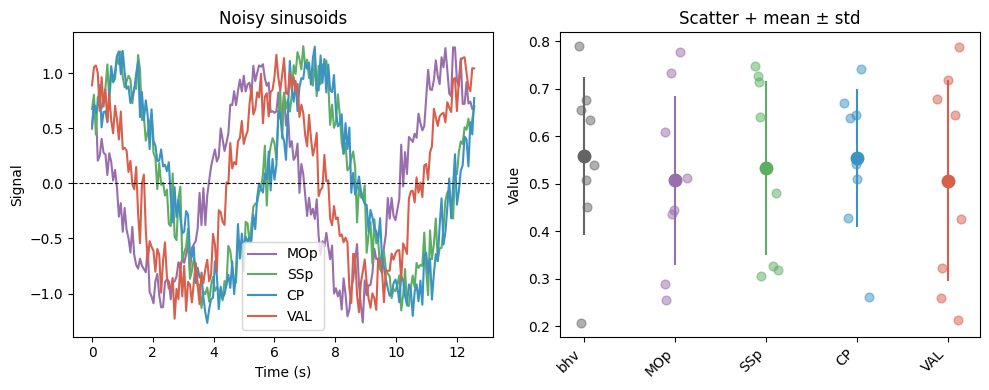

In [46]:

rng = np.random.default_rng(42)
x = np.linspace(0, 4 * np.pi, 200)
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# Left: noisy sinusoids per "area"
for label in ['MOp', 'SSp', 'CP', 'VAL']:
    c = getattr(colors, f'{label}_light', getattr(colors, label, 'steelblue'))
    y = np.sin(x + rng.uniform(0, np.pi)) + rng.normal(0, 0.15, len(x))
    axes[0].plot(x, y, label=label, color=c)
axes[0].axhline(0, color='k', linestyle='--', lw=0.8)
axes[0].set_xlabel('Time (s)')
axes[0].set_ylabel('Signal')
axes[0].set_title('Noisy sinusoids')
axes[0].legend()

# Right: scatter with error bars
areas = ['bhv', 'MOp', 'SSp', 'CP', 'VAL']
vals  = rng.uniform(0.2, 0.8, (len(areas), 8))
for i, area in enumerate(areas):
    c = getattr(colors, f'{area}_light', getattr(colors, area, 'steelblue'))
    jitter = rng.uniform(-0.15, 0.15, vals.shape[1])
    axes[1].scatter(i + jitter, vals[i], color=c, alpha=0.5, s=40, zorder=3)
    axes[1].errorbar(i, vals[i].mean(), yerr=vals[i].std(),
                     fmt='o', color=c, capsize=0, ms=9, zorder=4)
axes[1].set_xticks(range(len(areas)))
axes[1].set_xticklabels(areas, rotation=45, ha='right')
axes[1].set_ylabel('Value')
axes[1].set_title('Scatter + mean ± std')

plt.tight_layout()
# fig.savefig("rc_style_test.pdf")
plt.show()


In [3]:
data_dir='/data/bnd-data/raw/'
session='M061_2025_03_06_14_00'

In [5]:
df_ = pyal.load_pyaldata(data_dir + session[:4] + "/" + session)
df_ = dsp.preprocess(
    df_,
    only_trials=False,
    combine_time_bins=False, 
    # repair_time_varying_fields=['MotSen1_X', 'MotSen1_Y']
)

fields: ['values_before_camera_trigger', 'idx_before_camera_trigger'] could not be converted to int.


/home/me24/repos/pyaldata/pyaldata/utils.py:155: UserWarning: values_MotSen1_X might be a time-varying field. It matches the length of all_spikes on 99.85052316890882% of trials
  warnings.warn(
/home/me24/repos/pyaldata/pyaldata/utils.py:155: UserWarning: idx_MotSen1_X might be a time-varying field. It matches the length of all_spikes on 99.85052316890882% of trials
  warnings.warn(
/home/me24/repos/pyaldata/pyaldata/utils.py:155: UserWarning: values_MotSen1_Y might be a time-varying field. It matches the length of all_spikes on 99.85052316890882% of trials
  warnings.warn(
/home/me24/repos/pyaldata/pyaldata/utils.py:155: UserWarning: idx_MotSen1_Y might be a time-varying field. It matches the length of all_spikes on 99.85052316890882% of trials
  warnings.warn(


['all_spikes', 'SSp_spikes', 'VAL_spikes', 'GPe_spikes', 'CP_spikes', 'MOp_spikes']
Resulting all_spikes ephys data shape is (NxT): (11, 60000)
Resulting SSp_spikes ephys data shape is (NxT): (69, 60000)
Resulting VAL_spikes ephys data shape is (NxT): (168, 60000)
Resulting GPe_spikes ephys data shape is (NxT): (120, 60000)
Resulting CP_spikes ephys data shape is (NxT): (172, 60000)
Resulting MOp_spikes ephys data shape is (NxT): (178, 60000)


In [6]:
ALL_BHV_FIELDS = [
    "left_ankle",
    "left_elbow",
    "left_foot",
    "left_knee",
    "left_paw",
    "left_wrist",
    "right_ankle",
    "right_elbow",
    "right_foot",
    "right_knee",
    "right_paw",
    "right_wrist",
]

FORE_KEYWORDS = [
    "wrist",
    "paw",
    "elbow",
]

HIND_KEYWORDS = [
    "foot",
    "ankle",
    "knee",
]


def get_limb(forelimb: bool, laterality: str):
    if forelimb:
        body_parts = FORE_KEYWORDS
    else:
        body_parts = HIND_KEYWORDS

    bhv_fields = [
        field
        for field in ALL_BHV_FIELDS
        if (laterality in field) and any(body_part in field for body_part in body_parts)
    ]
    return bhv_fields

feature_dims = np.arange(start=2, stop=len(ALL_BHV_FIELDS)*3, step=3)


In [12]:
df__ = dt.add_pca_df(df_.iloc[1:])

In [ ]:
# compute_perturbation_metric is defined in tools/kinematics/disturb_score.py
# and exported via tools.kinematics


In [53]:
df = kin.compute_perturbation_metric(df__, bhv_fields=Params.oscillating_key_points)

# Select trials and drop nans
df_tr = pyal.select_trials(df, df.trial_name == 'trial')
df_tr_dropped = kin.drop_immobile_trials(df_tr, min_immobile_bins=5)

# df_tr = kin.drop_immobile_trials_from_td(df_tr, p=2, win=10, event_onset=(100, 500))
mask = df_tr["disturb_score"].apply(
    lambda x: isinstance(x, np.ndarray) and not np.any(np.isnan(x))
)
df_tr = df_tr.loc[mask]

df_tr['disturb_mean'] = df_tr['disturb_score'].apply(lambda a: np.mean(a))
df_tr['disturb_sum'] = df_tr['disturb_score'].apply(lambda a: np.log10(np.abs(np.sum(a))))

# # Add instantaneous phase
disturbances = np.sum(np.stack(df_tr.disturb_score.values), axis=1)
dstrb_idx = np.argsort(disturbances)


Skipped 40 trials
Otsu immobility threshold: 2.9536
Dropped 48 of 333 rows (14.41%).


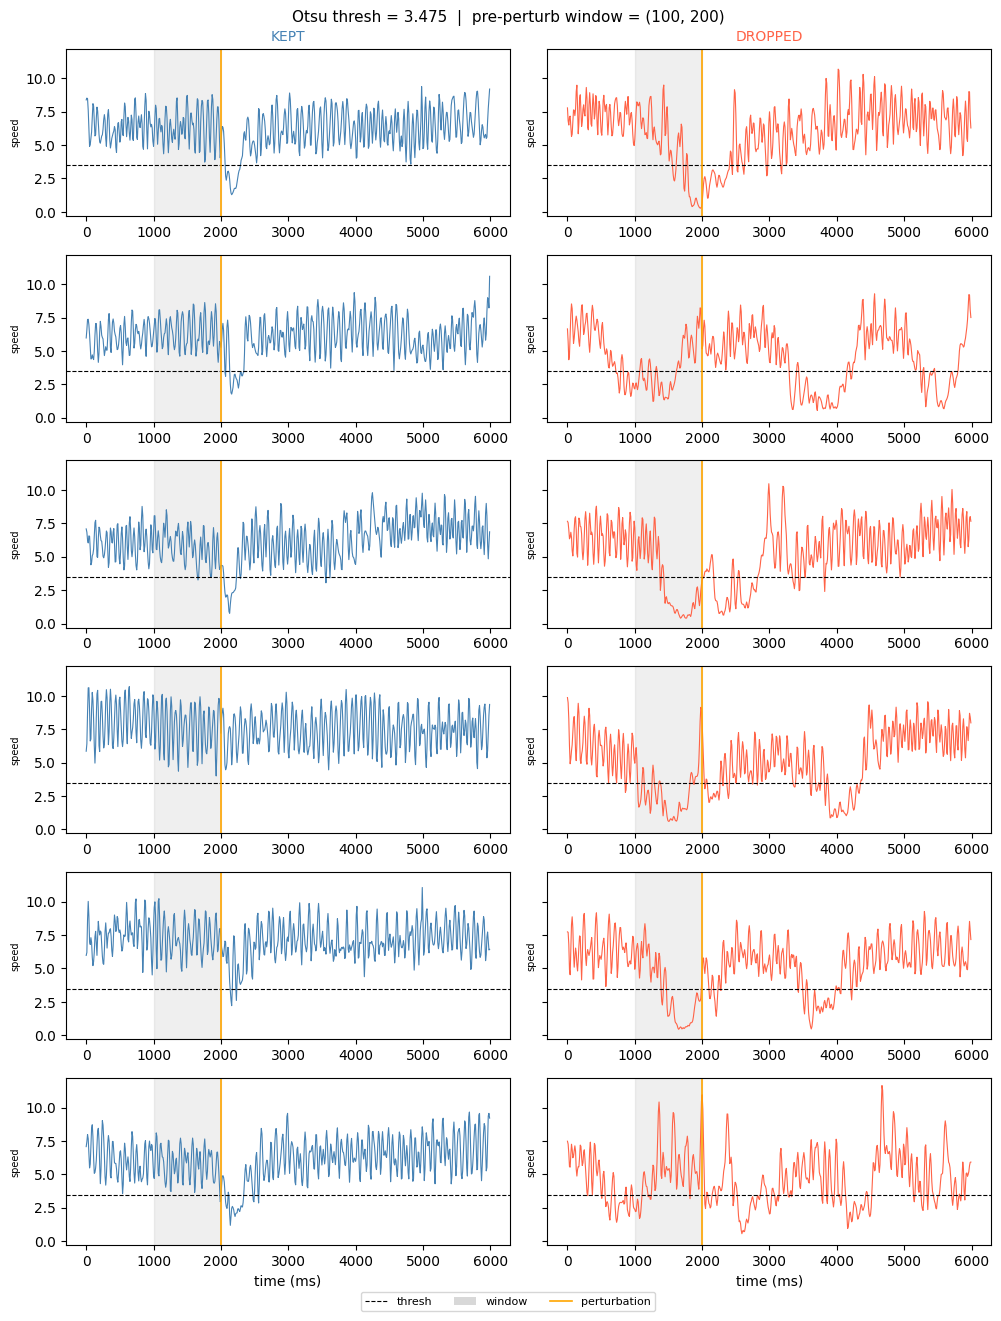

In [45]:
from tools.kinematics.utils import otsu_threshold

def _trial_speed(bhv_arr):
    vel = np.gradient(bhv_arr, axis=0)
    return np.linalg.norm(vel, axis=1)

pooled_log_speed = np.log(np.maximum(
    np.concatenate([_trial_speed(arr) for arr in df_tr.bhv.values]), 1e-10
))
thresh = np.exp(otsu_threshold(pooled_log_speed))

kept_idx = df_tr_dropped.index
dropped_idx = df_tr.index.difference(kept_idx)

PRE_PERTURB_WINDOW = (100, 200)
N_EXAMPLES = 6  # per group

fig, axes = plt.subplots(N_EXAMPLES, 2, figsize=(10, N_EXAMPLES * 2.2), sharex=False, sharey=True)
fig.suptitle(f"Otsu thresh = {thresh:.3f}  |  pre-perturb window = {PRE_PERTURB_WINDOW}", fontsize=11)
axes[0, 0].set_title("KEPT", fontsize=10, color="steelblue")
axes[0, 1].set_title("DROPPED", fontsize=10, color="tomato")

for col, (idx_pool, color) in enumerate([(kept_idx, "steelblue"), (dropped_idx, "tomato")]):
    sample = np.random.choice(idx_pool, size=min(N_EXAMPLES, len(idx_pool)), replace=False)
    for row, idx in enumerate(sample):
        row_data = df_tr.loc[idx]
        speed = _trial_speed(row_data.bhv)
        ax = axes[row, col]
        t = np.arange(len(speed)) * 10
        ax.plot(t, speed, color=color, lw=0.8)
        ax.axhline(thresh, color="k", linestyle="--", lw=0.8)
        ax.axvspan(PRE_PERTURB_WINDOW[0] * 10, PRE_PERTURB_WINDOW[1] * 10, alpha=0.12, color="gray")
        ax.axvline(row_data.idx_sol_on * 10, color="orange", lw=1.2)
        ax.set_ylabel("speed", fontsize=7)
        if row == N_EXAMPLES - 1:
            ax.set_xlabel("time (ms)")

from matplotlib.lines import Line2D
from matplotlib.patches import Patch
handles = [
    Line2D([0], [0], color="k", linestyle="--", lw=0.8, label="thresh"),
    Patch(facecolor="gray", alpha=0.3, label="window"),
    Line2D([0], [0], color="orange", lw=1.2, label="perturbation"),
]
fig.legend(handles=handles, loc="lower center", ncol=3, fontsize=8, bbox_to_anchor=(0.5, -0.01))

plt.tight_layout()
plt.show()


In [46]:
df_design = df_tr.copy()
idx_to_keep = 200
df_design = df_design.iloc[sorted(dstrb_idx[2:idx_to_keep])]
df_design_ = df_design.sample(frac=1, random_state=42).reset_index(drop=True)

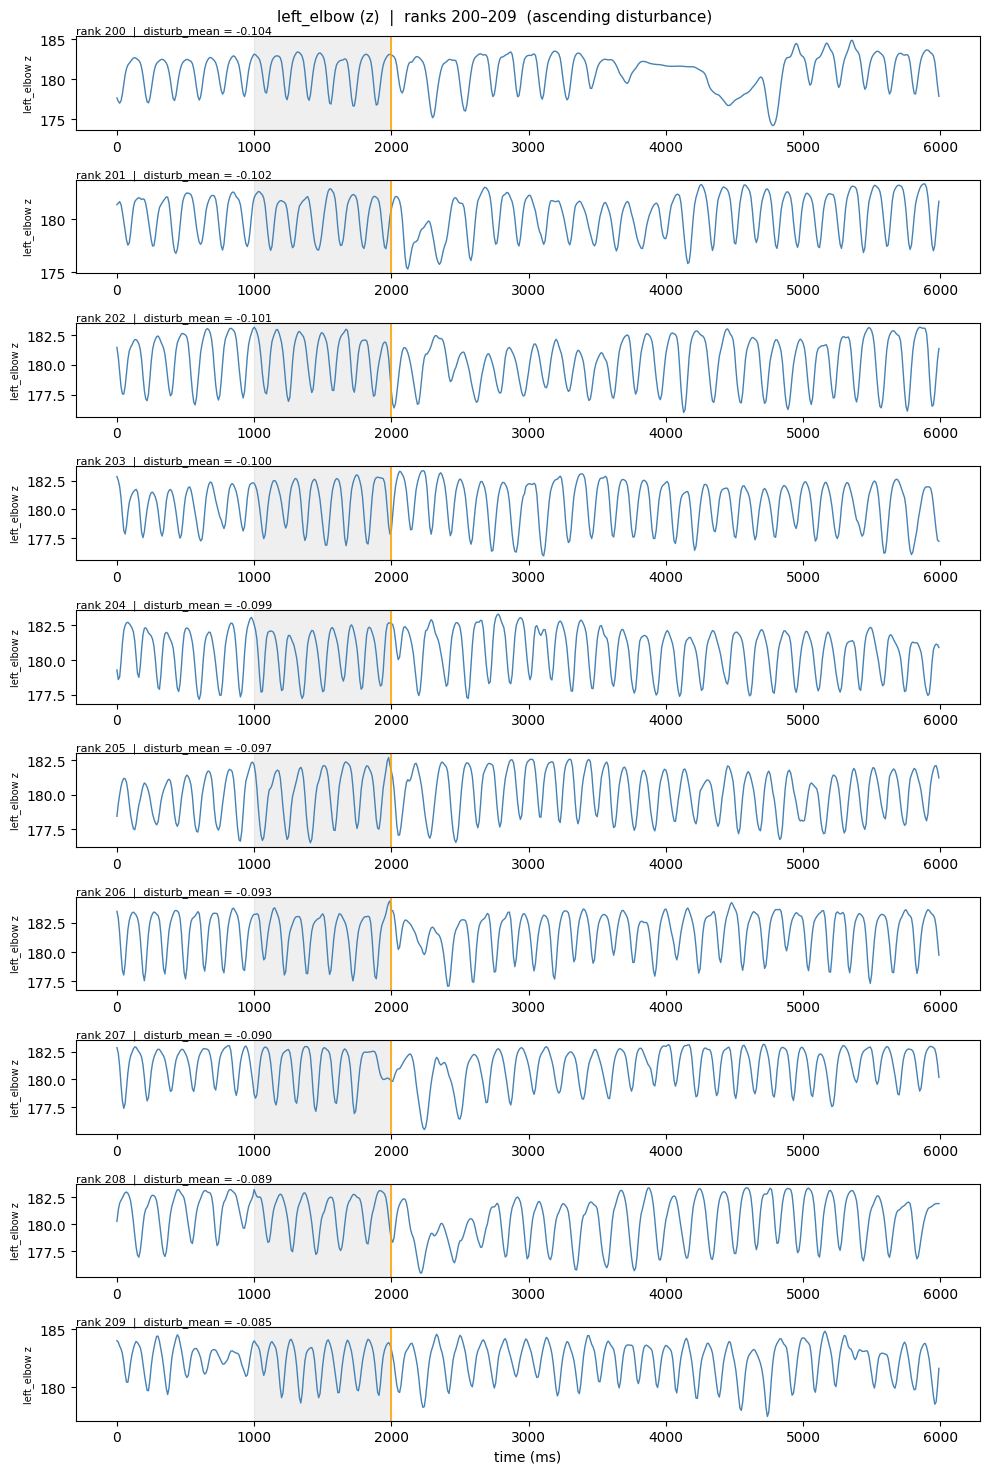

In [67]:
# --- Parameters ---
PAGE = 20
PAGE_SIZE = 10
KEYPOINT = 'left_elbow'   # any name in Params.oscillating_key_points
DIM = 2                   # 0=x, 1=y, 2=z (vertical)
# ------------------

kp_idx = list(Params.oscillating_key_points).index(KEYPOINT)
col_idx = kp_idx * 3 + DIM
dim_label = ['x', 'y', 'z'][DIM]

start = PAGE * PAGE_SIZE
end = start + PAGE_SIZE
trial_indices = dstrb_idx[start:end]

fig, axes = plt.subplots(PAGE_SIZE, 1, figsize=(10, PAGE_SIZE * 1.5), sharex=False)
fig.suptitle(f"{KEYPOINT} ({dim_label})  |  ranks {start}–{end - 1}  (ascending disturbance)", fontsize=11)

for row, idx in enumerate(trial_indices):
    row_data = df_tr.loc[df_tr.index[idx]]
    trace = row_data.bhv[:, col_idx]
    t = np.arange(len(trace)) * 10
    ax = axes[row]
    ax.plot(t, trace, color="steelblue", lw=1)
    ax.axvspan(PRE_PERTURB_WINDOW[0] * 10, PRE_PERTURB_WINDOW[1] * 10, alpha=0.12, color="gray")
    ax.axvline(row_data.idx_sol_on * 10, color="orange", lw=1.2)
    disturb_mean = row_data.disturb_mean if hasattr(row_data, 'disturb_mean') else np.log10(np.abs(np.sum(row_data.disturb_score)))
    ax.set_title(f"rank {start + row}  |  disturb_mean = {disturb_mean:.3f}", fontsize=8, loc="left", pad=2)
    ax.set_ylabel(f"{KEYPOINT} {dim_label}", fontsize=7)
    if row == PAGE_SIZE - 1:
        ax.set_xlabel("time (ms)")

plt.tight_layout()
plt.show()


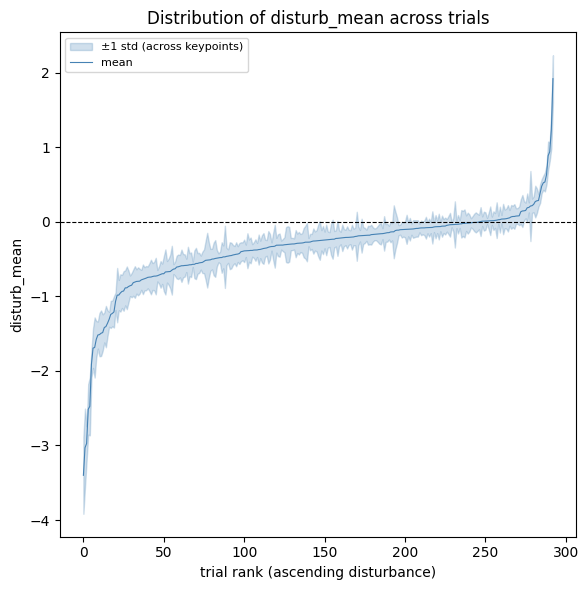

In [70]:
disturb_mean_sorted = df_tr['disturb_mean'].values[dstrb_idx]
disturb_std_sorted = df_tr['disturb_score'].apply(np.std).values[dstrb_idx]

x = np.arange(len(disturb_mean_sorted))
fig, ax = plt.subplots(figsize=(6, 6))
ax.fill_between(x, disturb_mean_sorted - disturb_std_sorted, disturb_mean_sorted + disturb_std_sorted,
                color="steelblue", alpha=0.25, label="±1 std (across keypoints)")
ax.plot(x, disturb_mean_sorted, color="steelblue", lw=0.8, label="mean")
ax.axhline(0, color="k", linestyle="--", lw=0.8)
ax.set_xlabel("trial rank (ascending disturbance)")
ax.set_ylabel("disturb_mean")
ax.set_title("Distribution of disturb_mean across trials")
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()


# Refactored loading

In [ ]:
def load_and_process_session(session, data_dir='/data/raw/', bhv_fields=None, min_immobile_bins=5):
    """
    Full pipeline for a session:
      1. Load raw pyalData
      2. Preprocess (remove low-firing neurons, keep 10 ms bins)
      3. Fit PCA on all rows except the first (free locomotion period)
      4. Compute perturbation metric (bhv_concat, Morlet power, disturb_score)
      5. Filter to perturbation trials, drop immobile, drop NaN scores
      6. Add disturb_mean / disturb_sum and sort by disturbance

    Returns
    -------
    df_tr      : pd.DataFrame  filtered, annotated trial table
    dstrb_idx  : np.ndarray    indices that sort df_tr ascending by disturbance
    """
    if bhv_fields is None:
        bhv_fields = Params.oscillating_key_points

    # 1 & 2 — load + preprocess
    df = pyal.load_pyaldata(data_dir + session[:4] + "/" + session)
    df = dsp.preprocess(df, only_trials=False, combine_time_bins=False)

    # 3 — PCA excluding the first row (free locomotion period)
    df = dt.add_pca_df(df.iloc[1:])

    # 4 — perturbation metric
    df = kin.compute_perturbation_metric(df, bhv_fields=bhv_fields)

    # 5 — filter trials
    df_tr = pyal.select_trials(df, df.trial_name == 'trial')
    df_tr = kin.drop_immobile_trials(df_tr, min_immobile_bins=min_immobile_bins)
    mask = df_tr["disturb_score"].apply(
        lambda x: isinstance(x, np.ndarray) and not np.any(np.isnan(x))
    )
    df_tr = df_tr.loc[mask]

    # 6 — derived metrics + sort order
    df_tr['disturb_mean'] = df_tr['disturb_score'].apply(np.mean)
    df_tr['disturb_sum'] = df_tr['disturb_score'].apply(lambda a: np.log10(np.abs(np.sum(a))))
    disturbances = np.sum(np.stack(df_tr.disturb_score.values), axis=1)
    dstrb_idx = np.argsort(disturbances)

    return df_tr, dstrb_idx


# df_tr, dstrb_idx = load_and_process_session(session)
# print(f"Trials retained: {len(df_tr)}")


In [3]:
def decode_direction_by_area(td, areas, window=20, step=2, k=5, shuffle=False, rnd=None):
    """
    Run moving-window direction decoding (values_Sol_direction) for each area.

    Parameters
    ----------
    td     : pd.DataFrame  trial table restricted to the epoch of interest
    areas  : list[str]     area names (resolved to '{area}_rates_pca') or raw
                           column names (e.g. 'bhv') used directly if the
                           '_rates_pca' variant is absent
    window : int           sliding window length in bins
    step   : int           step size in bins
    k      : int           number of CV folds (StratifiedKFold)

    Returns
    -------
    results : dict  {area: {'scores': ndarray (folds × time), 'times': ndarray}}
    """
    y = np.array(td.values_Sol_direction.values.tolist(), dtype=int)
    cv = StratifiedKFold(n_splits=k, shuffle=shuffle, random_state=rnd)
    results = {}
    for area in areas:
        pca_label = f"{area}_rates_pca"
        if pca_label in td.columns:
            label = pca_label
        elif area in td.columns:
            label = area
        else:
            print(f"  {area}: no column '{pca_label}' or '{area}' found, skipping")
            continue
        X = np.stack(td[label].values)
        scores, times = decode.moving_window_decoding(
            X, y, cv=cv, window_length_bin=window, step_bin=step,
        )
        results[area] = {"scores": scores, "times": times}
        print(f"  {area}: done  (mean acc = {np.mean(scores):.3f})")
    return results


# --- Run ---
AREAS = ['MOp', 'SSp', 'CP', 'VAL', 'bhv']



In [4]:
def plot_decoding_by_area(results, areas, chance=None, peak_lags=None):
    """Plot mean ± SEM decoding curves (left) and per-fold CoM summary (right)."""
    show_com = peak_lags is not None and any(
        "com_folds" in peak_lags.get(a, {}) for a in areas
    )
    show_com = False
    if show_com:
        fig, (ax, ax_com) = plt.subplots(
            1, 2, figsize=(10, 8), gridspec_kw={"width_ratios": [3, 1]}
        )
    else:
        fig, ax = plt.subplots(figsize=(8, 6))
        ax_com = None

    for area in areas:
        if area not in results:
            continue
        scores = results[area]["scores"]
        times  = results[area]["times"]
        color = getattr(colors, f'{area}_light', None)
        vizutils.shaded_errorbar(ax, times - 2, scores, color=color, label=area)

    if chance is not None:
        ax.axhline(chance, color="k", linestyle="dashed", label="chance")
    ax.axvline(0, color="gray", linestyle="dashed", label="perturb")

    # peak-lag dots at the top
    if peak_lags is not None:
        y_top = ax.get_ylim()[1]
        dot_y = y_top * 0.97
        for area in areas:
            if area not in peak_lags:
                continue
            color = getattr(colors, f'{area}_light')
            ax.scatter(peak_lags[area]["peak"], dot_y, color=color,
                       s=80, zorder=5, clip_on=False)

    ax.set_xlabel("Time rel. perturb. (s)")
    ax.set_ylabel("Decoding Accuracy (%)")
    ax.set_title("Direction decoding by area")
    ax.legend(frameon=False)

    # CoM subplot
    if show_com and ax_com is not None:
        present = [a for a in areas if a in peak_lags and "com_folds" in peak_lags[a]]
        x_pos = np.arange(len(present))
        for i, area in enumerate(present):
            c = getattr(colors, area, "steelblue")
            mean  = peak_lags[area]["com_mean"]
            std   = peak_lags[area]["com_std"]
            folds = peak_lags[area]["com_folds"]
            ax_com.scatter(np.full_like(folds, i, dtype=float), folds,
                           color=c, alpha=0.4, s=25, zorder=3)
            ax_com.errorbar(i, mean, yerr=std, fmt="o", color=c,
                            capsize=4, capthick=1.5, ms=7, zorder=4)
        ax_com.axhline(0, color="gray", linestyle=":", lw=0.8)
        ax_com.set_xticks(x_pos)
        ax_com.set_xticklabels(present, rotation=45, ha="right")
        ax_com.set_ylabel("CoM lag (s)")
        ax_com.set_title("CoM per fold")

    plt.tight_layout()
    return fig, ax



In [5]:
from scipy.ndimage import uniform_filter1d

SMOOTH_BINS = 5   # smoothing kernel width in bins
TIME_OFFSET = 2   # same shift applied in plot_decoding_by_area (times - 2)
MIN_RISE_BINS = 3 # consecutive bins above threshold to call rise time


def compute_peak_lags(results, chance, smooth_bins=SMOOTH_BINS, time_offset=TIME_OFFSET, min_rise_bins=MIN_RISE_BINS):
    """
    For each area compute two lag estimates.
    times are shifted by time_offset to match the plot x-axis.

    acc_max      : peak decoding accuracy of the smoothed mean curve
    peak_lag     : argmax of the smoothed mean curve
    com_lag      : CoM of above-chance area on the smoothed mean curve
    com_per_fold : CoM computed independently per fold → mean ± std reported
    rise_lag     : first time (>= 0) the smoothed mean exceeds chance + 2*mean_fold_std
                   for at least min_rise_bins consecutive bins (nan if never)
    rise_thresh  : the threshold used (chance + 2 * mean cross-fold SD)
    """
    lags = {}
    for area, res in results.items():
        scores = res["scores"]   # (time × folds)
        times  = res["times"] - time_offset

        mean_curve = np.mean(scores, axis=1)
        # smoothed   = uniform_filter1d(mean_curve, size=smooth_bins)
        smoothed = mean_curve

        # peak of smoothed mean
        peak_lag = times[np.argmax(smoothed)]
        acc_max  = float(np.max(smoothed))

        # CoM of smoothed mean
        above = np.maximum(smoothed - chance, 0.0)
        total = above.sum()
        com_lag = (above * times).sum() / total if total > 0 else np.nan

        # per-fold CoM
        n_folds = scores.shape[1]
        fold_coms = []
        for f in range(n_folds):
            fold_smooth = uniform_filter1d(scores[:, f], size=smooth_bins)
            above_f = np.maximum(fold_smooth - chance, 0.0)
            tot_f = above_f.sum()
            fold_coms.append((above_f * times).sum() / tot_f if tot_f > 0 else np.nan)
        fold_coms = np.array(fold_coms)

        # rise time: first crossing of chance + 2*mean_fold_std, restricted to post-perturbation (times >= 0)
        mean_fold_std = np.std(scores, axis=1).mean()
        rise_thresh = chance + 2 * mean_fold_std
        post_mask = times >= 0
        above_thresh = (smoothed > rise_thresh) & post_mask
        rise_lag = np.nan
        post_indices = np.where(post_mask)[0]
        for t in post_indices[:len(post_indices) - min_rise_bins + 1]:
            if np.all(above_thresh[t:t + min_rise_bins]):
                rise_lag = times[t]
                break

        lags[area] = {
            "peak": peak_lag,
            "acc_max": acc_max,
            "com": com_lag,
            "com_folds": fold_coms,
            "com_mean": np.nanmean(fold_coms),
            "com_std":  np.nanstd(fold_coms),
            "rise": rise_lag,
            "rise_thresh": float(rise_thresh),
        }
        print(f"  {area:6s}  peak = {peak_lag:+.3f} s   acc_max = {acc_max:.3f}   CoM = {com_lag:+.3f} s  "
              f"(fold CoM: {np.nanmean(fold_coms):+.3f} \u00b1 {np.nanstd(fold_coms):.3f} s)  "
              f"rise = {rise_lag:+.3f} s  (thresh = {rise_thresh:.3f})" if not np.isnan(rise_lag) else
              f"  {area:6s}  peak = {peak_lag:+.3f} s   acc_max = {acc_max:.3f}   CoM = {com_lag:+.3f} s  "
              f"(fold CoM: {np.nanmean(fold_coms):+.3f} \u00b1 {np.nanstd(fold_coms):.3f} s)  "
              f"rise = nan  (thresh = {rise_thresh:.3f})")
    return lags


# Run on all sessions

In [27]:
sessions = [
    'M061_2025_03_04_10_00', 
    'M061_2025_03_05_14_00', 
    'M061_2025_03_06_14_00',
    'M063_2025_03_13_14_00',
    'M063_2025_03_14_15_30', 
    'M062_2025_03_20_14_00',
    'M062_2025_03_21_14_00',
    'M078_2025_08_06_15_00',
    'M086_2025_12_10_15_00'
]

In [28]:

# --- Step 1: Load & preprocess all sessions into intermediate dict ---
all_session_processed = {}  # {session: {'td': perturb_td_shuff, 'chance': float} or None}

for sess in tqdm(sessions, desc="Loading sessions"):
    print(f"\n{'='*60}\n{sess}\n{'='*60}")
    try:
        df_tr_s, dstrb_idx_s = load_and_process_session(sess, data_dir=data_dir)

        disturb_mean_vals_s = df_tr_s['disturb_mean'].values
        threshold_s = -scipy.stats.sem(disturb_mean_vals_s)
        disturb_mean_sorted_s = disturb_mean_vals_s[dstrb_idx_s]
        idx_to_keep_s = int(np.searchsorted(disturb_mean_sorted_s, threshold_s))
        print(f"  threshold = {threshold_s:.3f}  |  trials selected: {idx_to_keep_s}")

        df_design_s = df_tr_s.iloc[sorted(dstrb_idx_s[:idx_to_keep_s])]
        perturb_td_s = pyal.restrict_to_interval(
            df_design_s, start_point_name='idx_sol_on', rel_start=-200, rel_end=300
        )
        perturb_td_s = dt.add_bhv(perturb_td_s)
        perturb_td_shuff_s = perturb_td_s.sample(frac=1, random_state=42).reset_index(drop=False)

        y_s = np.array(perturb_td_shuff_s.values_Sol_direction.values.tolist(), dtype=int)
        chance_s = np.max(np.bincount(y_s)) / len(y_s)
        print(f"  chance = {chance_s:.3f}  |  n_trials = {len(perturb_td_shuff_s)}")

        all_session_processed[sess] = {'td': perturb_td_shuff_s, 'chance': chance_s}

    except Exception as e:
        import traceback
        print(f"  ERROR loading {sess}: {e}")
        traceback.print_exc()
        all_session_processed[sess] = None

print(f"\nLoaded {sum(v is not None for v in all_session_processed.values())}/{len(sessions)} sessions successfully.")


Loading sessions:   0%|          | 0/9 [00:00<?, ?it/s]


M061_2025_03_04_10_00
fields: ['values_before_camera_trigger', 'idx_before_camera_trigger'] could not be converted to int.
fields: ['idx_motion'] could not be converted to int.
fields: ['values_Sol_direction', 'idx_Sol_direction', 'values_Sol_duration', 'idx_Sol_duration', 'idx_sol_on'] could not be converted to int.
['all_spikes', 'VAL_spikes', 'SSp_spikes', 'GPe_spikes', 'MOp_spikes', 'CP_spikes']


/home/me24/repos/pyaldata/pyaldata/utils.py:155: UserWarning: values_MotSen1_X might be a time-varying field. It matches the length of all_spikes on 99.8529411764706% of trials
  warnings.warn(
/home/me24/repos/pyaldata/pyaldata/utils.py:155: UserWarning: idx_MotSen1_X might be a time-varying field. It matches the length of all_spikes on 99.8529411764706% of trials
  warnings.warn(
/home/me24/repos/pyaldata/pyaldata/utils.py:155: UserWarning: values_MotSen1_Y might be a time-varying field. It matches the length of all_spikes on 99.8529411764706% of trials
  warnings.warn(
/home/me24/repos/pyaldata/pyaldata/utils.py:155: UserWarning: idx_MotSen1_Y might be a time-varying field. It matches the length of all_spikes on 99.8529411764706% of trials
  warnings.warn(


Resulting all_spikes ephys data shape is (NxT): (53, 60000)
Resulting VAL_spikes ephys data shape is (NxT): (240, 60000)
Resulting SSp_spikes ephys data shape is (NxT): (59, 60000)
Resulting GPe_spikes ephys data shape is (NxT): (112, 60000)
Resulting MOp_spikes ephys data shape is (NxT): (206, 60000)
Resulting CP_spikes ephys data shape is (NxT): (225, 60000)
Skipped 54 trials
Otsu immobility threshold: 2.2328
Dropped 47 of 339 rows (13.86%).
  threshold = -0.030  |  trials selected: 207


/tmp/ipykernel_2284454/62045419.py:16: UserWarning: Dropping 1 trials because of invalid time indexing. For more information, try warn_per_trial=True
  perturb_td_s = pyal.restrict_to_interval(
Loading sessions:  11%|█         | 1/9 [00:59<07:52, 59.08s/it]

...

  chance = 0.112  |  n_trials = 286

M086_2025_12_10_15_00
fields: ['values_before_camera_trigger', 'idx_before_camera_trigger', 'values_Sol_direction', 'values_Sol_duration'] could not be converted to int.
fields: ['values_before_camera_trigger', 'values_Sol_direction', 'idx_Sol_direction', 'values_Sol_duration', 'idx_Sol_duration', 'idx_sol_on'] could not be converted to int.
fields: ['values_before_camera_trigger', 'values_Sol_direction', 'idx_Sol_direction', 'values_Sol_duration', 'idx_Sol_duration', 'idx_sol_on'] could not be converted to int.
['MOp_spikes', 'all_spikes', 'CP_spikes', 'SSp_spikes', 'VAL_spikes']


/home/me24/repos/pyaldata/pyaldata/utils.py:155: UserWarning: values_MotSen1_X might be a time-varying field. It matches the length of MOp_spikes on 99.85875706214689% of trials
  warnings.warn(
/home/me24/repos/pyaldata/pyaldata/utils.py:155: UserWarning: idx_MotSen1_X might be a time-varying field. It matches the length of MOp_spikes on 99.85875706214689% of trials
  warnings.warn(
/home/me24/repos/pyaldata/pyaldata/utils.py:155: UserWarning: values_MotSen1_Y might be a time-varying field. It matches the length of MOp_spikes on 99.85875706214689% of trials
  warnings.warn(
/home/me24/repos/pyaldata/pyaldata/utils.py:155: UserWarning: idx_MotSen1_Y might be a time-varying field. It matches the length of MOp_spikes on 99.85875706214689% of trials
  warnings.warn(


Resulting MOp_spikes ephys data shape is (NxT): (199, 48000)
Resulting all_spikes ephys data shape is (NxT): (96, 48000)
Resulting CP_spikes ephys data shape is (NxT): (199, 48000)
Resulting SSp_spikes ephys data shape is (NxT): (149, 48000)
Resulting VAL_spikes ephys data shape is (NxT): (72, 48000)
Skipped 34 trials
Otsu immobility threshold: 4.4447
Dropped 160 of 353 rows (45.33%).
  threshold = -0.024  |  trials selected: 157


Loading sessions: 100%|██████████| 9/9 [06:49<00:00, 45.54s/it]

  chance = 0.115  |  n_trials = 157

Loaded 9/9 sessions successfully.


Decoding sessions:   0%|          | 0/9 [00:00<?, ?it/s]


M061_2025_03_04_10_00


100%|██████████| 482/482 [00:15<00:00, 31.02it/s]


  MOp: done  (mean acc = 0.138)


100%|██████████| 482/482 [00:07<00:00, 63.98it/s]


...

  CP: done  (mean acc = 0.133)


100%|██████████| 482/482 [00:16<00:00, 28.55it/s]


  VAL: done  (mean acc = 0.117)


100%|██████████| 482/482 [00:08<00:00, 55.00it/s]


  bhv: done  (mean acc = 0.103)
  MOp     peak = +0.220 s   acc_max = 0.520   CoM = +0.544 s  (fold CoM: +0.596 ± 0.054 s)
  SSp     peak = +0.230 s   acc_max = 0.242   CoM = +0.503 s  (fold CoM: +0.685 ± 0.192 s)
  CP      peak = +0.260 s   acc_max = 0.397   CoM = +0.569 s  (fold CoM: +0.524 ± 0.061 s)
  VAL     peak = +0.320 s   acc_max = 0.346   CoM = +0.422 s  (fold CoM: +0.486 ± 0.179 s)
  bhv     peak = +0.250 s   acc_max = 0.503   CoM = +0.258 s  (fold CoM: +0.289 ± 0.131 s)


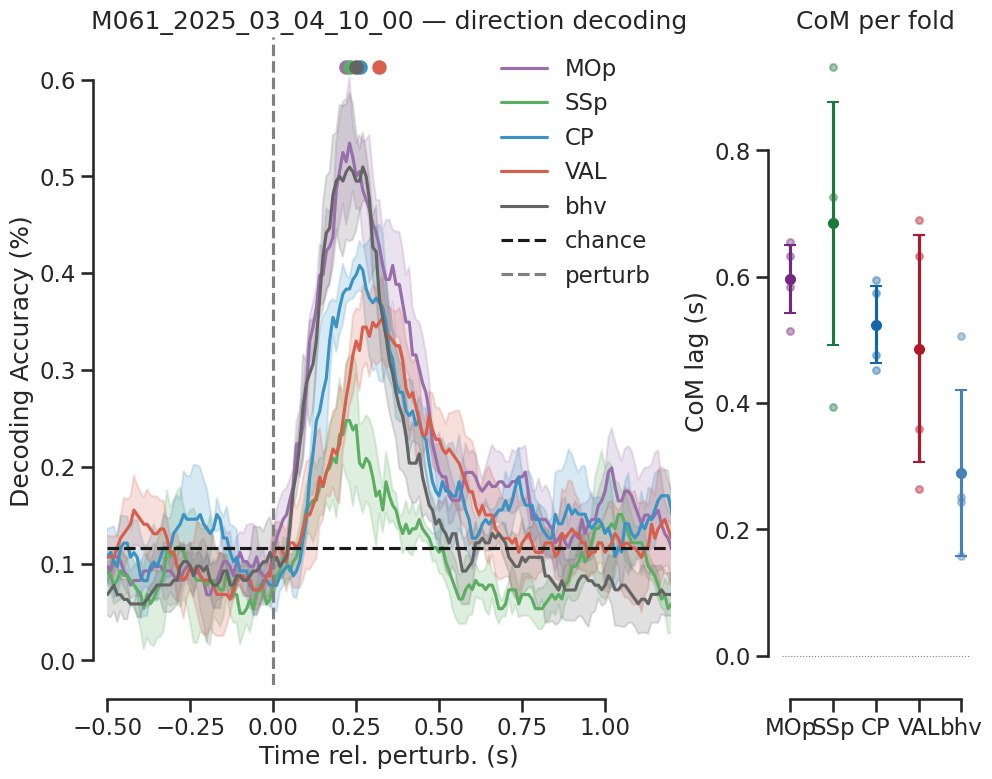

Decoding sessions:  11%|█         | 1/9 [01:04<08:39, 64.90s/it]


M061_2025_03_05_14_00


100%|██████████| 482/482 [00:10<00:00, 47.28it/s]


  MOp: done  (mean acc = 0.115)


100%|██████████| 482/482 [00:09<00:00, 53.27it/s]


...

  CP: done  (mean acc = 0.123)


100%|██████████| 482/482 [00:12<00:00, 39.90it/s]


  VAL: done  (mean acc = 0.107)


100%|██████████| 482/482 [00:05<00:00, 81.91it/s]


  bhv: done  (mean acc = 0.116)
  MOp     peak = +0.230 s   acc_max = 0.324   CoM = +0.289 s  (fold CoM: +0.386 ± 0.100 s)
  SSp     peak = +0.200 s   acc_max = 0.261   CoM = +0.768 s  (fold CoM: +0.755 ± 0.278 s)
  CP      peak = +0.350 s   acc_max = 0.348   CoM = +0.210 s  (fold CoM: +0.292 ± 0.165 s)
  VAL     peak = +0.290 s   acc_max = 0.207   CoM = +0.140 s  (fold CoM: +0.402 ± 0.274 s)
  bhv     peak = +0.250 s   acc_max = 0.384   CoM = +0.603 s  (fold CoM: +0.573 ± 0.328 s)


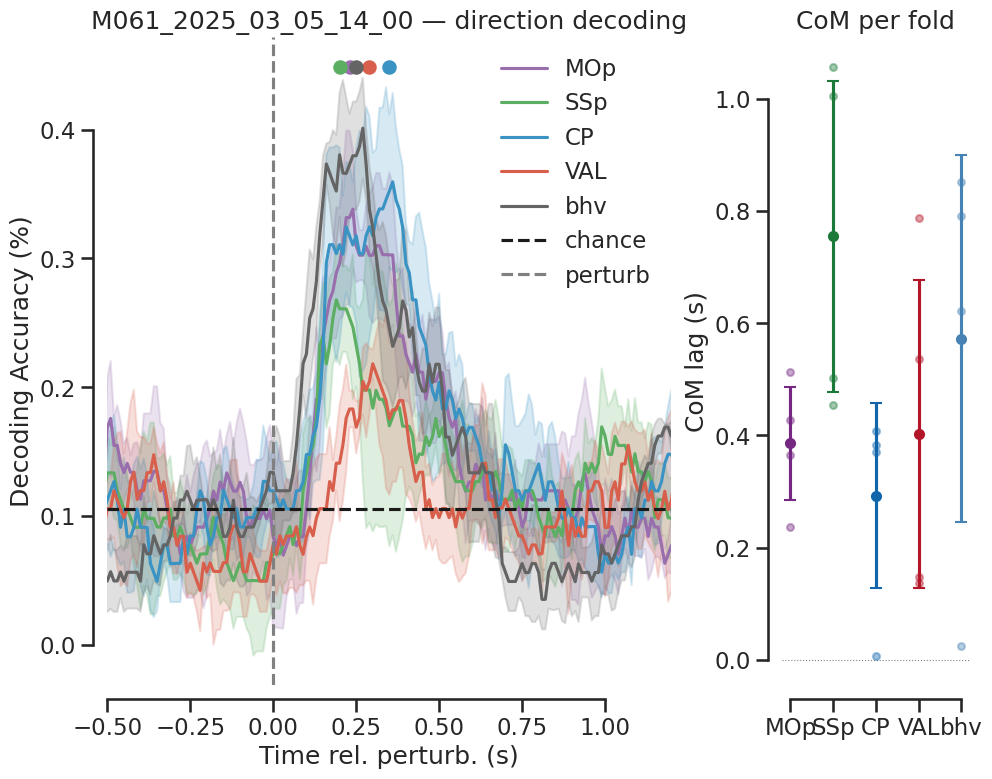

Decoding sessions:  22%|██▏       | 2/9 [01:53<06:29, 55.60s/it]


M061_2025_03_06_14_00


100%|██████████| 482/482 [00:14<00:00, 33.62it/s]


  MOp: done  (mean acc = 0.132)


100%|██████████| 482/482 [00:09<00:00, 52.68it/s]


...

  CP: done  (mean acc = 0.131)


100%|██████████| 482/482 [00:14<00:00, 33.82it/s]


  VAL: done  (mean acc = 0.126)


100%|██████████| 482/482 [00:10<00:00, 47.92it/s]


  bhv: done  (mean acc = 0.119)
  MOp     peak = +0.230 s   acc_max = 0.405   CoM = +0.379 s  (fold CoM: +0.368 ± 0.048 s)
  SSp     peak = +0.270 s   acc_max = 0.278   CoM = +0.372 s  (fold CoM: +0.345 ± 0.147 s)
  CP      peak = +0.280 s   acc_max = 0.320   CoM = +0.454 s  (fold CoM: +0.503 ± 0.090 s)
  VAL     peak = +0.310 s   acc_max = 0.306   CoM = +0.447 s  (fold CoM: +0.492 ± 0.169 s)
  bhv     peak = +0.240 s   acc_max = 0.481   CoM = +0.305 s  (fold CoM: +0.328 ± 0.091 s)


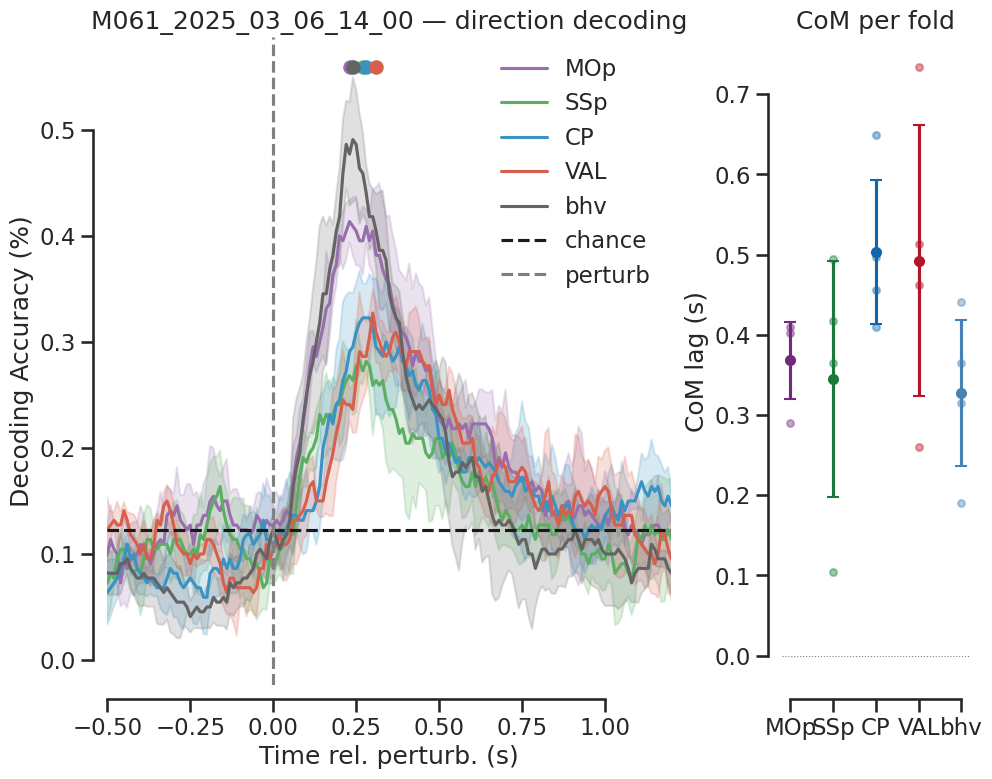

Decoding sessions:  33%|███▎      | 3/9 [02:55<05:50, 58.50s/it]


M063_2025_03_13_14_00


100%|██████████| 482/482 [00:11<00:00, 43.01it/s]


  MOp: done  (mean acc = 0.150)


100%|██████████| 482/482 [00:09<00:00, 51.69it/s]


...

  CP: done  (mean acc = 0.153)


100%|██████████| 482/482 [00:10<00:00, 46.40it/s]


  VAL: done  (mean acc = 0.144)


100%|██████████| 482/482 [00:06<00:00, 70.66it/s]


  bhv: done  (mean acc = 0.123)
  MOp     peak = -1.290 s   acc_max = 0.213   CoM = -0.041 s  (fold CoM: +0.227 ± 0.462 s)
  SSp     peak = +0.220 s   acc_max = 0.227   CoM = +0.699 s  (fold CoM: +0.749 ± 0.272 s)
  CP      peak = +0.300 s   acc_max = 0.195   CoM = -0.064 s  (fold CoM: +0.130 ± 0.509 s)
  VAL     peak = +0.330 s   acc_max = 0.213   CoM = +0.461 s  (fold CoM: +0.460 ± 0.227 s)
  bhv     peak = +0.130 s   acc_max = 0.296   CoM = +0.298 s  (fold CoM: +0.396 ± 0.300 s)


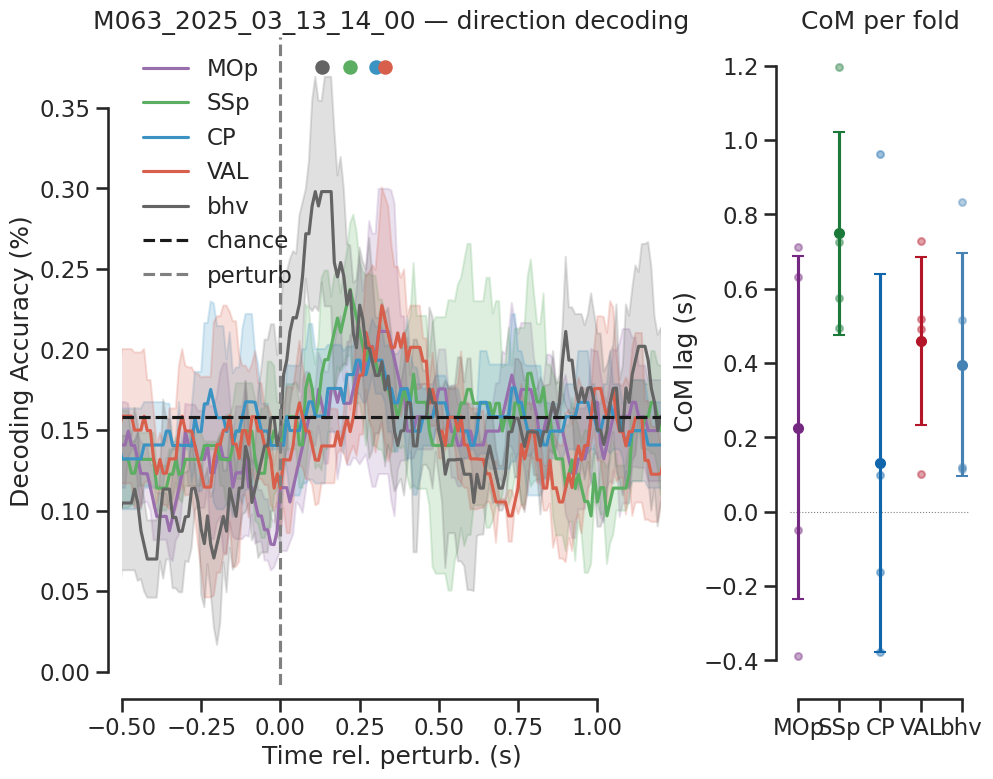

Decoding sessions:  44%|████▍     | 4/9 [03:51<04:46, 57.31s/it]


M063_2025_03_14_15_30


100%|██████████| 482/482 [00:09<00:00, 48.43it/s]


  MOp: done  (mean acc = 0.124)


100%|██████████| 482/482 [00:07<00:00, 62.09it/s]


...

  CP: done  (mean acc = 0.119)


100%|██████████| 482/482 [00:13<00:00, 35.08it/s]


  VAL: done  (mean acc = 0.117)


100%|██████████| 482/482 [00:07<00:00, 67.62it/s]


  bhv: done  (mean acc = 0.137)
  MOp     peak = +0.430 s   acc_max = 0.243   CoM = +0.318 s  (fold CoM: +0.368 ± 0.318 s)
  SSp     peak = +0.260 s   acc_max = 0.235   CoM = +0.267 s  (fold CoM: +0.345 ± 0.310 s)
  CP      peak = +0.470 s   acc_max = 0.210   CoM = +0.703 s  (fold CoM: +0.852 ± 0.428 s)
  VAL     peak = +0.260 s   acc_max = 0.194   CoM = +0.519 s  (fold CoM: +0.620 ± 0.400 s)
  bhv     peak = +0.240 s   acc_max = 0.381   CoM = +0.318 s  (fold CoM: +0.445 ± 0.130 s)


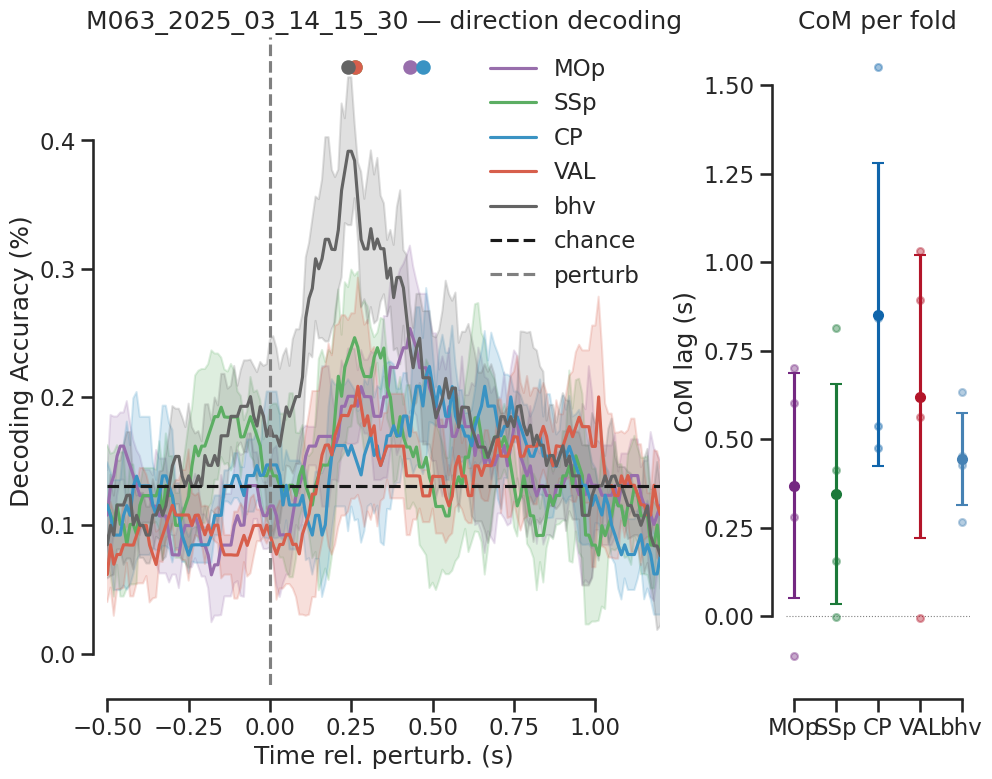

Decoding sessions:  56%|█████▌    | 5/9 [04:45<03:45, 56.25s/it]


M062_2025_03_20_14_00


100%|██████████| 482/482 [00:13<00:00, 35.23it/s]


  MOp: done  (mean acc = 0.104)


100%|██████████| 482/482 [00:11<00:00, 42.67it/s]


...

  CP: done  (mean acc = 0.109)


100%|██████████| 482/482 [00:13<00:00, 36.36it/s]


  VAL: done  (mean acc = 0.093)


100%|██████████| 482/482 [00:09<00:00, 49.32it/s]


  bhv: done  (mean acc = 0.118)
  MOp     peak = +0.220 s   acc_max = 0.257   CoM = +0.300 s  (fold CoM: +0.437 ± 0.200 s)
  SSp     peak = +0.290 s   acc_max = 0.225   CoM = +0.428 s  (fold CoM: +0.392 ± 0.179 s)
  CP      peak = +0.350 s   acc_max = 0.279   CoM = +0.527 s  (fold CoM: +0.524 ± 0.212 s)
  VAL     peak = -1.020 s   acc_max = 0.158   CoM = +0.348 s  (fold CoM: +0.561 ± 0.350 s)
  bhv     peak = +0.260 s   acc_max = 0.397   CoM = +0.376 s  (fold CoM: +0.401 ± 0.197 s)


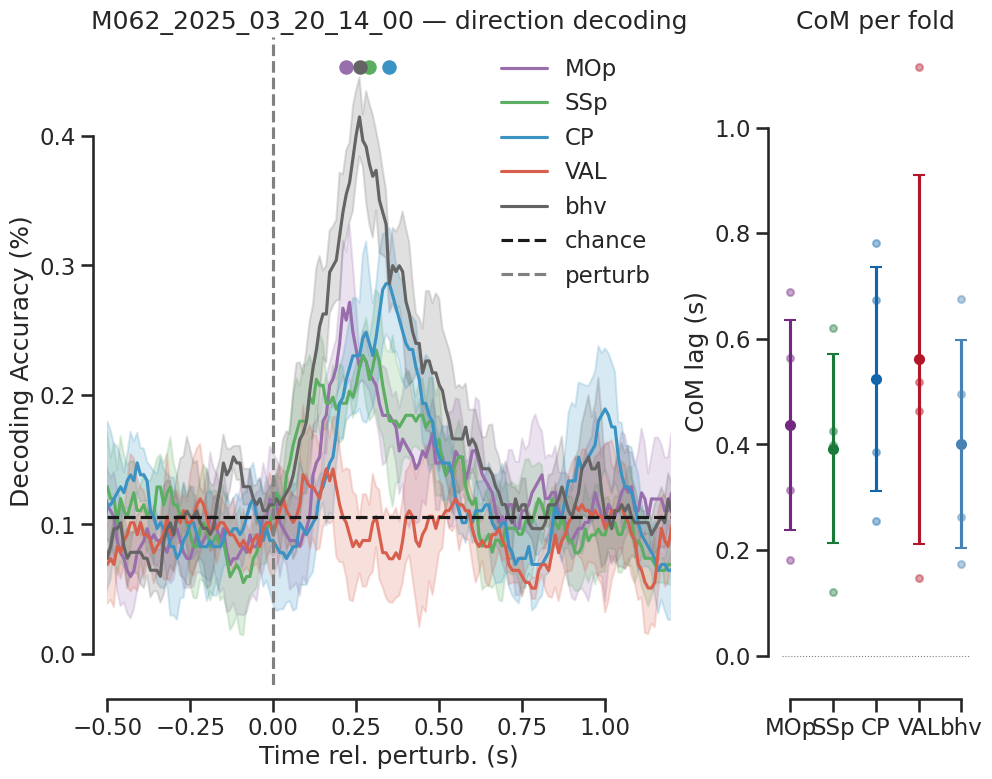

Decoding sessions:  67%|██████▋   | 6/9 [05:58<03:05, 61.71s/it]


M062_2025_03_21_14_00


100%|██████████| 482/482 [00:14<00:00, 32.29it/s]


  MOp: done  (mean acc = 0.104)


100%|██████████| 482/482 [00:09<00:00, 51.76it/s]


...

  CP: done  (mean acc = 0.110)


100%|██████████| 482/482 [00:11<00:00, 40.80it/s]


  VAL: done  (mean acc = 0.100)


100%|██████████| 482/482 [00:10<00:00, 47.66it/s]


  bhv: done  (mean acc = 0.098)
  MOp     peak = +0.290 s   acc_max = 0.236   CoM = +0.342 s  (fold CoM: +0.479 ± 0.142 s)
  SSp     peak = +0.250 s   acc_max = 0.234   CoM = +0.457 s  (fold CoM: +0.569 ± 0.189 s)
  CP      peak = +0.310 s   acc_max = 0.271   CoM = +0.388 s  (fold CoM: +0.392 ± 0.208 s)
  VAL     peak = +0.900 s   acc_max = 0.155   CoM = +0.542 s  (fold CoM: +0.577 ± 0.292 s)
  bhv     peak = +0.230 s   acc_max = 0.405   CoM = +0.317 s  (fold CoM: +0.425 ± 0.150 s)


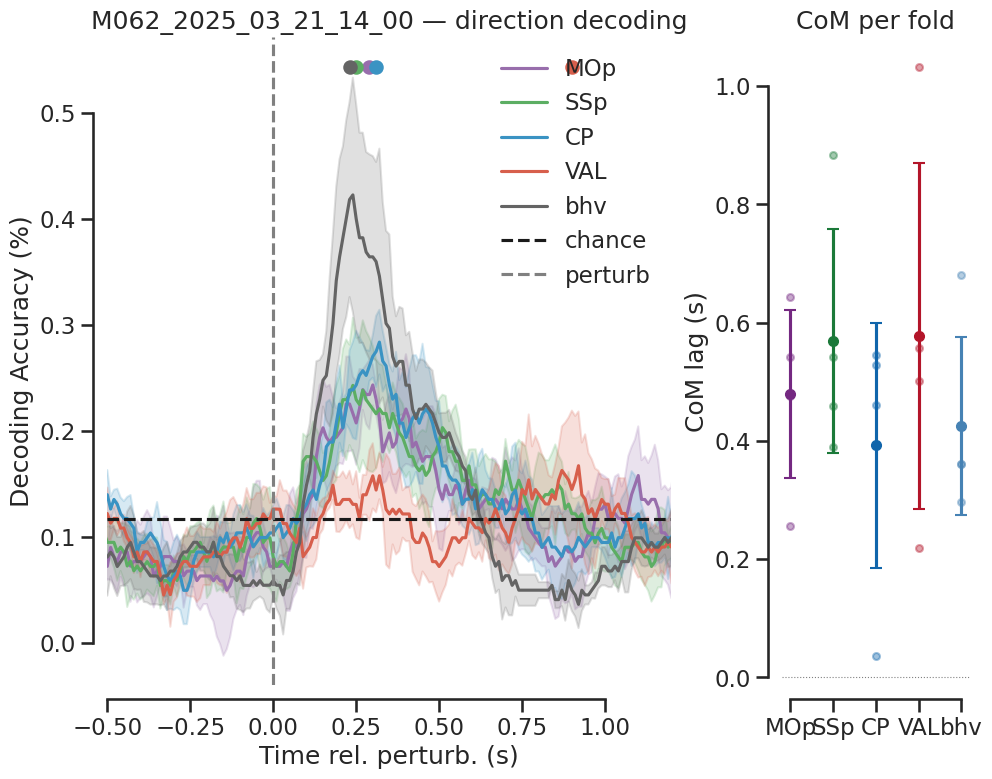

Decoding sessions:  78%|███████▊  | 7/9 [07:06<02:07, 63.76s/it]


M078_2025_08_06_15_00


100%|██████████| 482/482 [00:10<00:00, 44.08it/s]


  MOp: done  (mean acc = 0.106)


100%|██████████| 482/482 [00:11<00:00, 42.14it/s]


...

  CP: done  (mean acc = 0.107)


100%|██████████| 482/482 [00:18<00:00, 26.48it/s]


  VAL: done  (mean acc = 0.113)


100%|██████████| 482/482 [00:11<00:00, 43.53it/s]


  bhv: done  (mean acc = 0.111)
  MOp     peak = +0.300 s   acc_max = 0.317   CoM = +0.382 s  (fold CoM: +0.490 ± 0.094 s)
  SSp     peak = +0.260 s   acc_max = 0.297   CoM = +0.326 s  (fold CoM: +0.393 ± 0.007 s)
  CP      peak = +0.330 s   acc_max = 0.225   CoM = +0.428 s  (fold CoM: +0.610 ± 0.166 s)
  VAL     peak = +0.390 s   acc_max = 0.222   CoM = +0.559 s  (fold CoM: +0.650 ± 0.167 s)
  bhv     peak = +0.250 s   acc_max = 0.296   CoM = +0.421 s  (fold CoM: +0.533 ± 0.147 s)


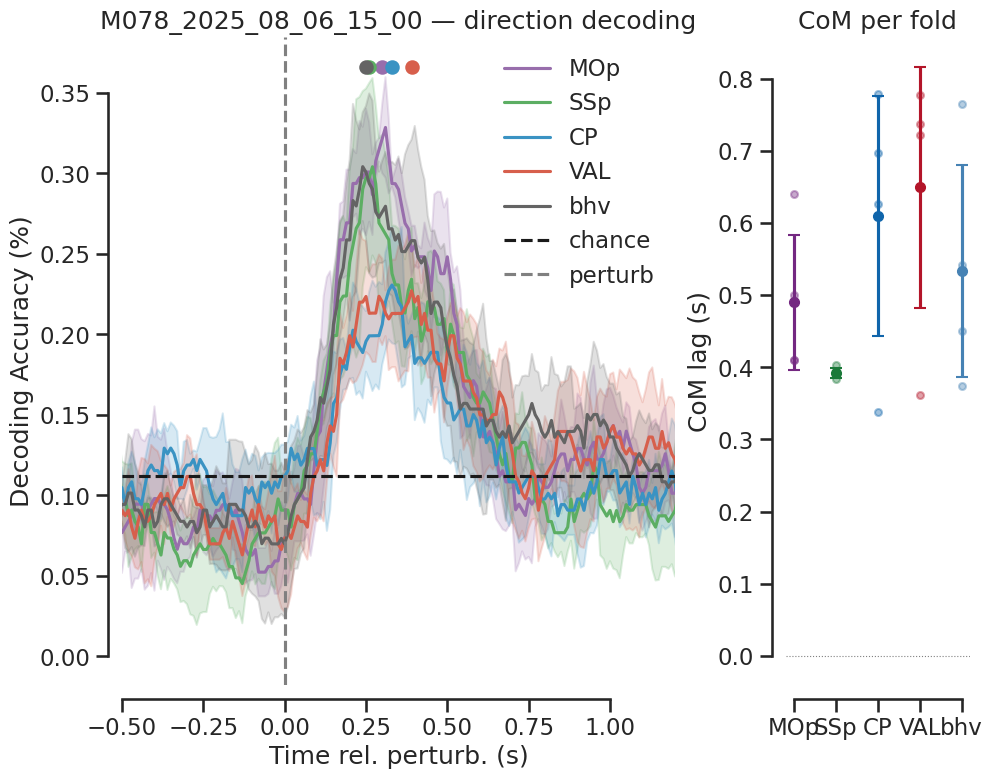

Decoding sessions:  89%|████████▉ | 8/9 [08:13<01:04, 64.98s/it]


M086_2025_12_10_15_00


100%|██████████| 482/482 [00:12<00:00, 38.61it/s]


  MOp: done  (mean acc = 0.127)


100%|██████████| 482/482 [00:10<00:00, 46.18it/s]


...

  CP: done  (mean acc = 0.130)


100%|██████████| 482/482 [00:06<00:00, 69.21it/s]


  VAL: done  (mean acc = 0.105)


100%|██████████| 482/482 [00:06<00:00, 76.42it/s]


  bhv: done  (mean acc = 0.138)
  MOp     peak = +0.290 s   acc_max = 0.278   CoM = +0.675 s  (fold CoM: +0.685 ± 0.287 s)
  SSp     peak = +0.250 s   acc_max = 0.555   CoM = +0.452 s  (fold CoM: +0.525 ± 0.158 s)
  CP      peak = +0.380 s   acc_max = 0.408   CoM = +0.525 s  (fold CoM: +0.636 ± 0.032 s)
  VAL     peak = +2.360 s   acc_max = 0.158   CoM = +0.728 s  (fold CoM: +0.778 ± 0.302 s)
  bhv     peak = +0.360 s   acc_max = 0.387   CoM = +0.632 s  (fold CoM: +0.659 ± 0.203 s)


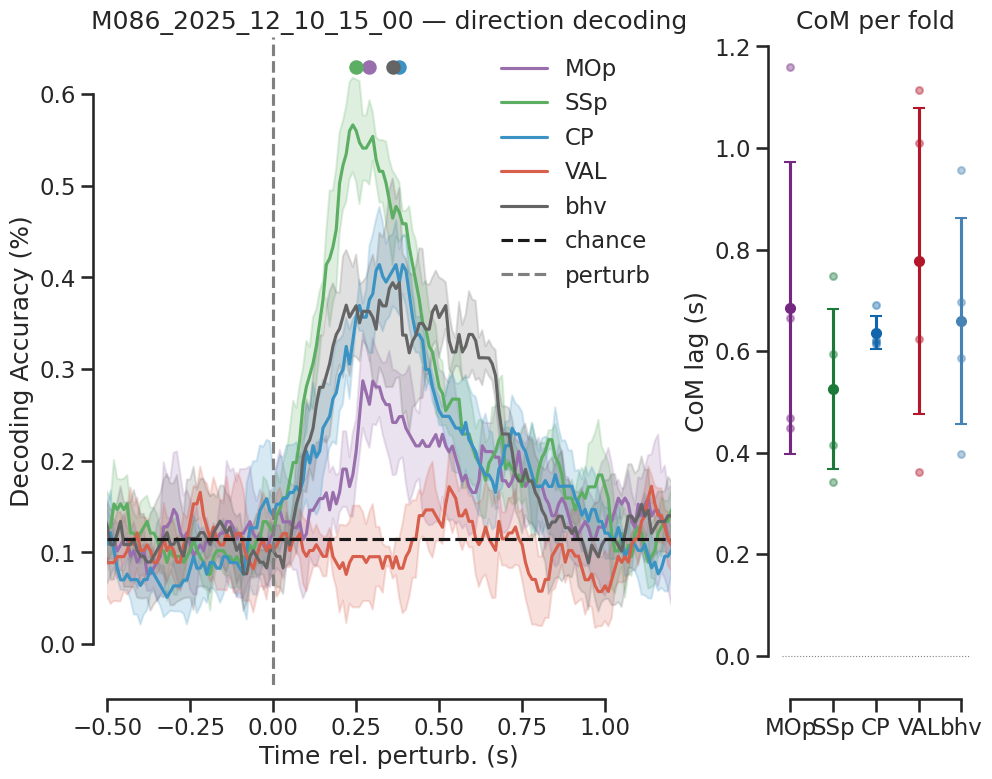

Decoding sessions: 100%|██████████| 9/9 [09:02<00:00, 60.29s/it]


--- Summary ---
  M061_2025_03_04_10_00  →  MOp: acc_max=0.520  peak=+0.220s  CoM=+0.596s  post_max=0.534  SSp: acc_max=0.242  peak=+0.230s  CoM=+0.685s  post_max=0.248  CP: acc_max=0.397  peak=+0.260s  CoM=+0.524s  post_max=0.408  VAL: acc_max=0.346  peak=+0.320s  CoM=+0.486s  post_max=0.354  bhv: acc_max=0.503  peak=+0.250s  CoM=+0.289s  post_max=0.510
  M061_2025_03_05_14_00  →  MOp: acc_max=0.324  peak=+0.230s  CoM=+0.386s  post_max=0.338  SSp: acc_max=0.261  peak=+0.200s  CoM=+0.755s  post_max=0.268  CP: acc_max=0.348  peak=+0.350s  CoM=+0.292s  post_max=0.360  VAL: acc_max=0.207  peak=+0.290s  CoM=+0.402s  post_max=0.218  bhv: acc_max=0.384  peak=+0.250s  CoM=+0.573s  post_max=0.401
  M061_2025_03_06_14_00  →  MOp: acc_max=0.405  peak=+0.230s  CoM=+0.368s  post_max=0.414  SSp: acc_max=0.278  peak=+0.270s  CoM=+0.345s  post_max=0.282  CP: acc_max=0.320  peak=+0.280s  CoM=+0.503s  post_max=0.323  VAL: acc_max=0.306  peak=+0.310s  CoM=+0.492s  post_max=0.327  bhv: acc_max=0.481  pe

In [29]:

# --- Step 2: Decode each session + diagnostic plot ---
all_session_lags = {}  # {session: {area: {...}, '_chance': float} or None}

for sess, proc in tqdm(all_session_processed.items(), desc="Decoding sessions"):
    if proc is None:
        all_session_lags[sess] = None
        continue
    print(f"\n{'='*60}\n{sess}\n{'='*60}")
    try:
        td       = proc['td']
        chance_s = proc['chance']

        results_s = decode_direction_by_area(td, AREAS, step=1, k=4)
        lags_s    = compute_peak_lags(results_s, chance_s)

        # Diagnostic: time vs accuracy curves for this session
        with vizutils.apply_plot_style():
            fig, ax = plot_decoding_by_area(results_s, AREAS, chance=chance_s, peak_lags=lags_s)
            ax.set_xlim(-0.5, 1.2)
            ax.set_title(f"{sess} — direction decoding")
        plt.show()

        sess_entry = {'_chance': chance_s}
        for area, info in lags_s.items():
            res = results_s[area]
            times = res["times"] - TIME_OFFSET
            post_mask = (times >= 0) & (times <= 1.0)
            post_perturb_max = float(np.mean(res["scores"][post_mask], axis=1).max()) if post_mask.any() else 0.0
            sess_entry[area] = {
                'acc_max':         info['acc_max'],
                'peak':            info['peak'],
                'com_mean':        info['com_mean'],
                'post_perturb_max': post_perturb_max,
            }
        all_session_lags[sess] = sess_entry

    except Exception as e:
        import traceback
        print(f"  ERROR decoding {sess}: {e}")
        traceback.print_exc()
        all_session_lags[sess] = None

print("\n--- Summary ---")
for s, lags in all_session_lags.items():
    if lags is not None:
        lag_str = "  ".join(
            f"{a}: acc_max={v['acc_max']:.3f}  peak={v['peak']:+.3f}s  CoM={v['com_mean']:+.3f}s  post_max={v['post_perturb_max']:.3f}"
            for a, v in lags.items() if not a.startswith('_')
        )
        print(f"  {s}  →  {lag_str}")
    else:
        print(f"  {s}  →  FAILED")


In [44]:
with open("all_session_lags.pkl", "wb") as f:
    pickle.dump(all_session_lags, f)

In [4]:
## load

with open("all_session_lags.pkl", "rb") as f:
    all_session_lags = pickle.load(f)

In [26]:

import copy

# Drop neural areas for M063 (keep bhv), drop VAL for M062 and M086
NEURAL_AREAS = ['MOp', 'SSp', 'CP', 'VAL']

all_session_lags_filt = {}
for sess, sess_lags in all_session_lags.items():
    if sess_lags is None:
        all_session_lags_filt[sess] = None
        continue
    entry = copy.deepcopy(sess_lags)
    if 'M063' in sess:
        for area in NEURAL_AREAS:
            entry.pop(area, None)
        print(f"  {sess}  →  dropped all neural areas")
    elif 'M062' in sess or 'M086' in sess:
        entry.pop('VAL', None)
        print(f"  {sess}  →  dropped VAL")
    all_session_lags_filt[sess] = entry


  M063_2025_03_13_14_00  →  dropped all neural areas
  M063_2025_03_14_15_30  →  dropped all neural areas
  M062_2025_03_20_14_00  →  dropped VAL
  M062_2025_03_21_14_00  →  dropped VAL
  M086_2025_12_10_15_00  →  dropped VAL


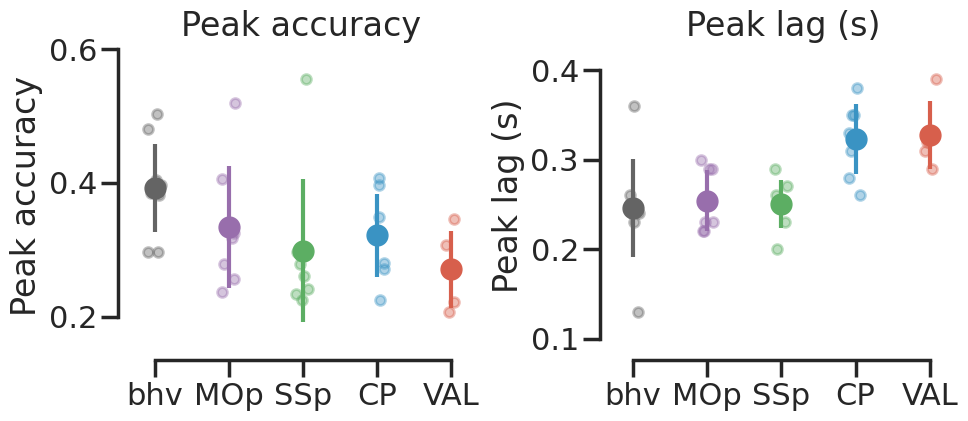

In [ ]:

# --- Aggregate across sessions ---
metrics = ['acc_max', 'peak']
metric_labels = ['Peak accuracy', 'Peak lag (s)']
PLOT_ORDER = ['bhv', 'MOp', 'SSp', 'CP', 'VAL']

# Fraction of the available range [chance, 1] that must be exceeded post-perturbation.
# e.g. 0.10 → area must decode at least 10% of the way from chance to perfect accuracy.
ABOVE_CHANCE_MARGIN = 0.10
JITTER = 0.1   # horizontal jitter width

# Build {area: {metric: [values across sessions]}}
agg = {area: {m: [] for m in metrics} for area in PLOT_ORDER}
for sess, sess_lags in all_session_lags_filt.items():
    if sess_lags is None:
        print(f"  {sess}  →  FAILED (skipping)")
        continue
    chance_sess = sess_lags.get('_chance', 0.0)
    threshold = chance_sess + ABOVE_CHANCE_MARGIN * (1.0 - chance_sess)
    for area in PLOT_ORDER:
        if area not in sess_lags:
            continue
        post_max = sess_lags[area].get('post_perturb_max', 0.0)
        if post_max <= threshold:
            print(f"  DROPPED  {sess}  {area:6s}  post_max={post_max:.3f}  threshold={threshold:.3f}")
            continue
        for m in metrics:
            val = sess_lags[area][m]
            if m == 'peak' and val < 0:
                continue
            agg[area][m].append(val)

rng_jitter = np.random.default_rng(0)

# --- Plot ---
with vizutils.apply_plot_style('poster'):
    fig, axes = plt.subplots(1, 2, figsize=(10, 5))

    for ax, metric, ylabel in zip(axes, metrics, metric_labels):
        present = [a for a in PLOT_ORDER if len(agg[a][metric]) > 0]
        x_pos = np.arange(len(present))
        all_vals = np.concatenate([agg[a][metric] for a in present])
        vmin, vmax = np.nanmin(all_vals), np.nanmax(all_vals)
        pad = (vmax - vmin) * 0.15
        ax.set_ylim(vmin - pad, vmax + pad)

        for i, area in enumerate(present):
            vals = np.array(agg[area][metric])
            mean = np.nanmean(vals)
            std  = np.nanstd(vals)
            c = getattr(colors, f'{area}_light', getattr(colors, area, 'steelblue'))
            jitter = rng_jitter.uniform(-JITTER, JITTER, size=len(vals))

            ax.scatter(i + jitter, vals, color=c, alpha=0.4, s=50, zorder=3)
            ax.errorbar(i, mean, yerr=std, fmt='o', color=c,
                        capsize=0, capthick=2, ms=15, zorder=4)

        ax.set_xticks(x_pos)
        ax.set_xticklabels(present, rotation=45, ha='right')
        ax.set_ylabel(ylabel)
        ax.set_title(ylabel)

    plt.tight_layout()
fig.savefig("direction_decoding_summary.pdf")
plt.show()


In [28]:

# Summary: how many sessions contribute per area after filtering
print(f"{'Area':<8}  sessions kept")
for area in ['bhv', 'MOp', 'SSp', 'CP', 'VAL']:
    kept = [s for s, lags in all_session_lags_filt.items()
            if lags is not None and area in lags]
    print(f"  {area:<6}  {len(kept)}  {kept}")


Area      sessions kept
  bhv     9  ['M061_2025_03_04_10_00', 'M061_2025_03_05_14_00', 'M061_2025_03_06_14_00', 'M063_2025_03_13_14_00', 'M063_2025_03_14_15_30', 'M062_2025_03_20_14_00', 'M062_2025_03_21_14_00', 'M078_2025_08_06_15_00', 'M086_2025_12_10_15_00']
  MOp     7  ['M061_2025_03_04_10_00', 'M061_2025_03_05_14_00', 'M061_2025_03_06_14_00', 'M062_2025_03_20_14_00', 'M062_2025_03_21_14_00', 'M078_2025_08_06_15_00', 'M086_2025_12_10_15_00']
  SSp     7  ['M061_2025_03_04_10_00', 'M061_2025_03_05_14_00', 'M061_2025_03_06_14_00', 'M062_2025_03_20_14_00', 'M062_2025_03_21_14_00', 'M078_2025_08_06_15_00', 'M086_2025_12_10_15_00']
  CP      7  ['M061_2025_03_04_10_00', 'M061_2025_03_05_14_00', 'M061_2025_03_06_14_00', 'M062_2025_03_20_14_00', 'M062_2025_03_21_14_00', 'M078_2025_08_06_15_00', 'M086_2025_12_10_15_00']
  VAL     4  ['M061_2025_03_04_10_00', 'M061_2025_03_05_14_00', 'M061_2025_03_06_14_00', 'M078_2025_08_06_15_00']


# Refactored running on all sessions

In [6]:
sessions = [
    'M061_2025_03_04_10_00', 
    'M061_2025_03_05_14_00', 
    'M061_2025_03_06_14_00',
    # 'M063_2025_03_13_14_00',
    # 'M063_2025_03_14_15_30', 
    'M062_2025_03_20_14_00',
    'M062_2025_03_21_14_00',
    'M078_2025_08_06_15_00',
    'M086_2025_12_10_15_00',
    "M103_2026_02_18_15_30",
    "M106_2026_02_25_15_00",
]

In [7]:
all_session_processed = dsp.load_sessions_for_trial_analyses(sessions, std=0.03, std_dropping=False)

Loading sessions:   0%|          | 0/9 [00:00<?, ?it/s]


M061_2025_03_04_10_00


fields: ['values_before_camera_trigger', 'idx_before_camera_trigger'] could not be converted to int.
fields: ['idx_motion'] could not be converted to int.
fields: ['values_Sol_direction', 'idx_Sol_direction', 'values_Sol_duration', 'idx_Sol_duration', 'idx_sol_on'] could not be converted to int.
['all_spikes', 'VAL_spikes', 'SSp_spikes', 'GPe_spikes', 'MOp_spikes', 'CP_spikes']


/home/me24/repos/pyaldata/pyaldata/utils.py:155: UserWarning: values_MotSen1_X might be a time-varying field. It matches the length of all_spikes on 99.8529411764706% of trials
  warnings.warn(
/home/me24/repos/pyaldata/pyaldata/utils.py:155: UserWarning: idx_MotSen1_X might be a time-varying field. It matches the length of all_spikes on 99.8529411764706% of trials
  warnings.warn(
/home/me24/repos/pyaldata/pyaldata/utils.py:155: UserWarning: values_MotSen1_Y might be a time-varying field. It matches the length of all_spikes on 99.8529411764706% of trials
  warnings.warn(
/home/me24/repos/pyaldata/pyaldata/utils.py:155: UserWarning: idx_MotSen1_Y might be a time-varying field. It matches the length of all_spikes on 99.8529411764706% of trials
  warnings.warn(


Resulting all_spikes ephys data shape is (NxT): (53, 60000)
Resulting VAL_spikes ephys data shape is (NxT): (240, 60000)
Resulting SSp_spikes ephys data shape is (NxT): (59, 60000)
Resulting GPe_spikes ephys data shape is (NxT): (112, 60000)
Resulting MOp_spikes ephys data shape is (NxT): (206, 60000)
Resulting CP_spikes ephys data shape is (NxT): (225, 60000)
Skipped 54 trials
Otsu immobility threshold: 2.2328
Dropped 47 of 339 rows (13.86%).
Thresh val dropping -2
  drop_trials_sem_crosses_zero: by SEM: 217  |  by value: 265  |  kept: 217/265 (81.9%)


...


M106_2026_02_25_15_00
fields: ['values_before_camera_trigger', 'idx_before_camera_trigger', 'values_Sol_duration', 'values_Sol_direction'] could not be converted to int.
fields: ['values_before_camera_trigger', 'values_Sol_duration', 'idx_Sol_duration', 'values_Sol_direction', 'idx_Sol_direction', 'idx_sol_on'] could not be converted to int.
fields: ['values_before_camera_trigger', 'values_Sol_duration', 'idx_Sol_duration', 'values_Sol_direction', 'idx_Sol_direction', 'idx_sol_on'] could not be converted to int.
['CP_spikes', 'MOp_spikes', 'all_spikes', 'VAL_spikes', 'SSp_spikes']


/home/me24/repos/pyaldata/pyaldata/utils.py:155: UserWarning: values_MotSen1_X might be a time-varying field. It matches the length of CP_spikes on 99.9001996007984% of trials
  warnings.warn(
/home/me24/repos/pyaldata/pyaldata/utils.py:155: UserWarning: idx_MotSen1_X might be a time-varying field. It matches the length of CP_spikes on 99.9001996007984% of trials
  warnings.warn(
/home/me24/repos/pyaldata/pyaldata/utils.py:155: UserWarning: values_MotSen1_Y might be a time-varying field. It matches the length of CP_spikes on 99.9001996007984% of trials
  warnings.warn(
/home/me24/repos/pyaldata/pyaldata/utils.py:155: UserWarning: idx_MotSen1_Y might be a time-varying field. It matches the length of CP_spikes on 99.9001996007984% of trials
  warnings.warn(


Resulting CP_spikes ephys data shape is (NxT): (206, 48000)
Resulting MOp_spikes ephys data shape is (NxT): (156, 48000)
Resulting all_spikes ephys data shape is (NxT): (11, 48000)
Resulting VAL_spikes ephys data shape is (NxT): (132, 48000)
Resulting SSp_spikes ephys data shape is (NxT): (142, 48000)
add_concat_perturb_time: dropping 1 trial(s) with missing idx_sol_on
Skipped 87 trials
Otsu immobility threshold: 2.2123
Dropped 130 of 499 rows (26.05%).
Thresh val dropping -2
  drop_trials_sem_crosses_zero: by SEM: 222  |  by value: 319  |  kept: 216/325 (66.5%)


Loading sessions: 100%|██████████| 9/9 [04:40<00:00, 31.22s/it]


Loaded 9/9 sessions successfully.


## Solenoid direction


M061_2025_03_04_10_00


  1%|▏         | 7/482 [00:00<00:14, 31.78it/s]

100%|██████████| 482/482 [00:19<00:00, 24.17it/s]


  MOp: done  (mean acc = 0.127)


100%|██████████| 482/482 [00:07<00:00, 62.70it/s]


...

  CP: done  (mean acc = 0.123)


100%|██████████| 482/482 [00:16<00:00, 28.56it/s]


  VAL: done  (mean acc = 0.113)


100%|██████████| 482/482 [00:06<00:00, 78.93it/s]


  bhv: done  (mean acc = 0.099)
  MOp     peak = +0.240 s   acc_max = 0.493   CoM = +0.453 s  (fold CoM: +0.458 ± 0.076 s)  rise = +0.090 s  (thresh = 0.167)
  SSp     peak = +0.240 s   acc_max = 0.295   CoM = +0.032 s  (fold CoM: +0.159 ± 0.227 s)  rise = +0.120 s  (thresh = 0.173)
  CP      peak = +0.270 s   acc_max = 0.392   CoM = +0.475 s  (fold CoM: +0.533 ± 0.127 s)  rise = +0.110 s  (thresh = 0.167)
  VAL     peak = +0.320 s   acc_max = 0.323   CoM = +0.154 s  (fold CoM: +0.155 ± 0.244 s)  rise = +0.170 s  (thresh = 0.162)
  bhv     peak = +0.260 s   acc_max = 0.539   CoM = +0.324 s  (fold CoM: +0.331 ± 0.079 s)  rise = +0.080 s  (thresh = 0.161)


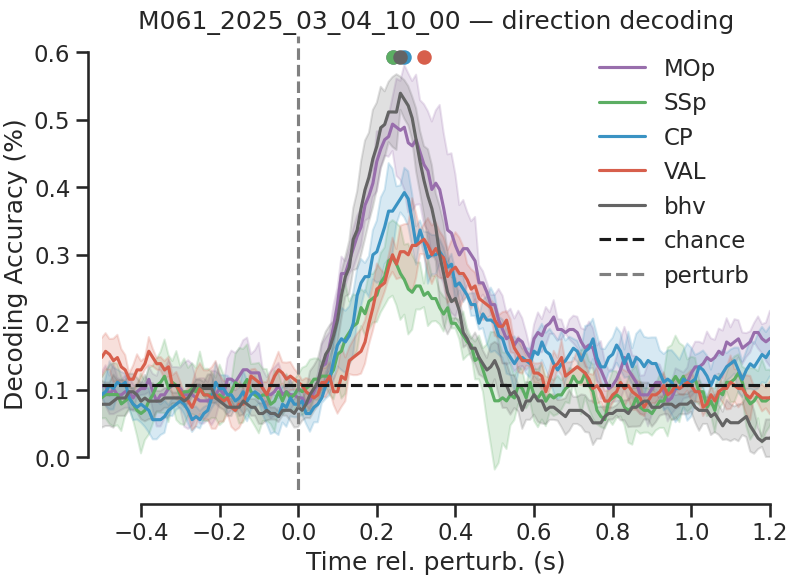


M061_2025_03_05_14_00


100%|██████████| 482/482 [00:10<00:00, 48.03it/s]


  MOp: done  (mean acc = 0.114)


100%|██████████| 482/482 [00:08<00:00, 53.80it/s]


  SSp: done  (mean acc = 0.108)


...

  CP: done  (mean acc = 0.122)


100%|██████████| 482/482 [00:12<00:00, 39.40it/s]


  VAL: done  (mean acc = 0.108)


100%|██████████| 482/482 [00:05<00:00, 87.39it/s]


  bhv: done  (mean acc = 0.104)
  MOp     peak = +0.240 s   acc_max = 0.351   CoM = +0.264 s  (fold CoM: +0.365 ± 0.040 s)  rise = +0.110 s  (thresh = 0.191)
  SSp     peak = +0.180 s   acc_max = 0.246   CoM = +0.346 s  (fold CoM: +0.427 ± 0.255 s)  rise = +0.140 s  (thresh = 0.186)
  CP      peak = +0.290 s   acc_max = 0.377   CoM = +0.212 s  (fold CoM: +0.218 ± 0.177 s)  rise = +0.120 s  (thresh = 0.192)
  VAL     peak = +0.280 s   acc_max = 0.227   CoM = +0.438 s  (fold CoM: +0.456 ± 0.149 s)  rise = +0.250 s  (thresh = 0.186)
  bhv     peak = +0.240 s   acc_max = 0.344   CoM = +0.163 s  (fold CoM: +0.198 ± 0.077 s)  rise = +0.090 s  (thresh = 0.186)


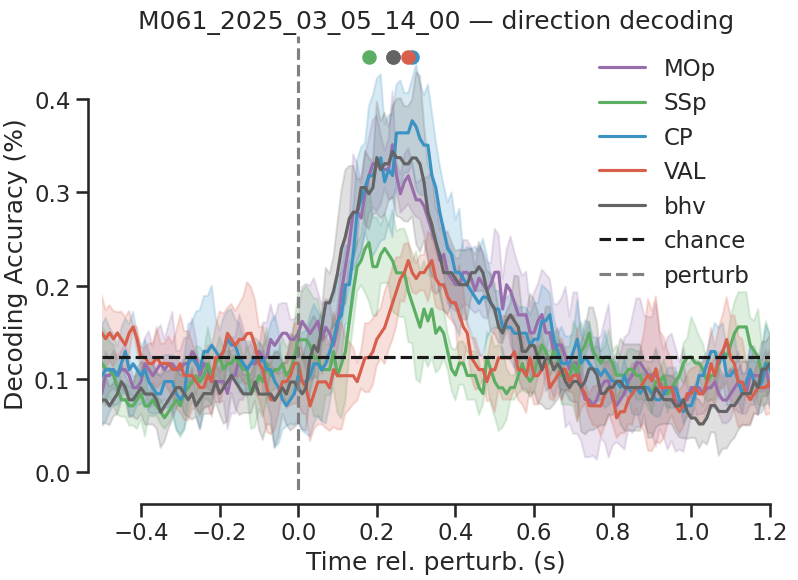


M061_2025_03_06_14_00


100%|██████████| 482/482 [00:13<00:00, 36.26it/s]


  MOp: done  (mean acc = 0.123)


100%|██████████| 482/482 [00:08<00:00, 56.76it/s]


  SSp: done  (mean acc = 0.105)


...

  CP: done  (mean acc = 0.127)


100%|██████████| 482/482 [00:12<00:00, 38.65it/s]


  VAL: done  (mean acc = 0.114)


100%|██████████| 482/482 [00:06<00:00, 76.54it/s]


  bhv: done  (mean acc = 0.102)
  MOp     peak = +0.240 s   acc_max = 0.475   CoM = +0.313 s  (fold CoM: +0.327 ± 0.142 s)  rise = +0.090 s  (thresh = 0.173)
  SSp     peak = +0.260 s   acc_max = 0.299   CoM = +0.300 s  (fold CoM: +0.341 ± 0.073 s)  rise = +0.100 s  (thresh = 0.174)
  CP      peak = +0.300 s   acc_max = 0.362   CoM = +0.521 s  (fold CoM: +0.584 ± 0.056 s)  rise = +0.120 s  (thresh = 0.175)
  VAL     peak = +0.310 s   acc_max = 0.290   CoM = +0.299 s  (fold CoM: +0.415 ± 0.154 s)  rise = +0.160 s  (thresh = 0.168)
  bhv     peak = +0.260 s   acc_max = 0.421   CoM = +0.278 s  (fold CoM: +0.251 ± 0.120 s)  rise = +0.080 s  (thresh = 0.167)


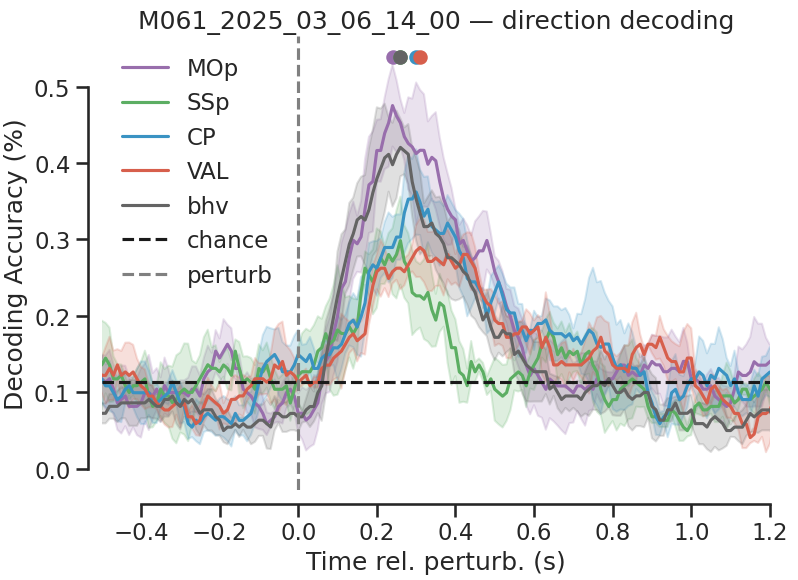


M062_2025_03_20_14_00


100%|██████████| 482/482 [00:12<00:00, 38.33it/s]


  MOp: done  (mean acc = 0.115)


100%|██████████| 482/482 [00:10<00:00, 47.07it/s]


  SSp: done  (mean acc = 0.106)


...

  CP: done  (mean acc = 0.121)


100%|██████████| 482/482 [00:12<00:00, 40.10it/s]


  VAL: done  (mean acc = 0.101)


100%|██████████| 482/482 [00:06<00:00, 79.72it/s]


  bhv: done  (mean acc = 0.114)
  MOp     peak = +0.240 s   acc_max = 0.267   CoM = +0.435 s  (fold CoM: +0.421 ± 0.172 s)  rise = +0.150 s  (thresh = 0.173)
  SSp     peak = +0.230 s   acc_max = 0.258   CoM = +0.488 s  (fold CoM: +0.529 ± 0.187 s)  rise = +0.110 s  (thresh = 0.171)
  CP      peak = +0.310 s   acc_max = 0.285   CoM = +0.385 s  (fold CoM: +0.488 ± 0.082 s)  rise = +0.150 s  (thresh = 0.172)
  VAL     peak = +1.200 s   acc_max = 0.154   CoM = +0.597 s  (fold CoM: +0.436 ± 0.262 s)  rise = nan  (thresh = 0.166)
  bhv     peak = +0.290 s   acc_max = 0.376   CoM = +0.281 s  (fold CoM: +0.303 ± 0.198 s)  rise = +0.090 s  (thresh = 0.178)


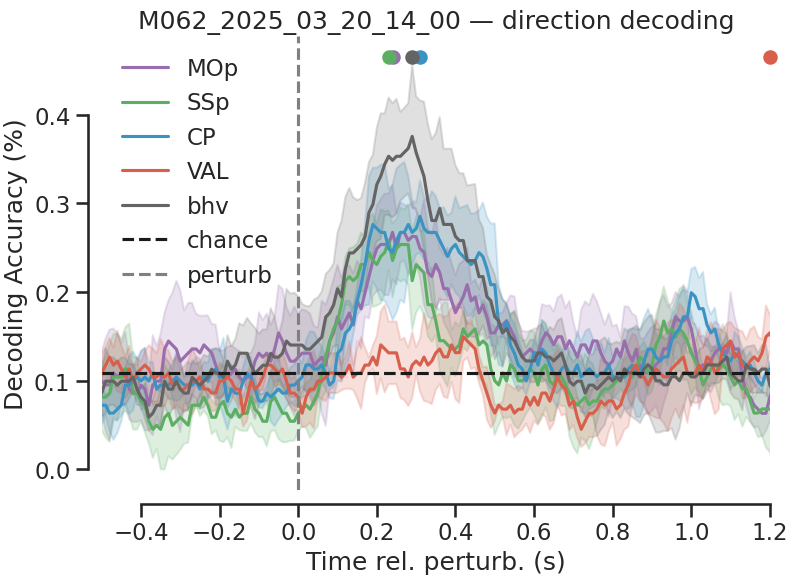


M062_2025_03_21_14_00


100%|██████████| 482/482 [00:13<00:00, 35.68it/s]


  MOp: done  (mean acc = 0.110)


100%|██████████| 482/482 [00:08<00:00, 58.55it/s]


  SSp: done  (mean acc = 0.102)


...

  CP: done  (mean acc = 0.107)


100%|██████████| 482/482 [00:10<00:00, 46.42it/s]


  VAL: done  (mean acc = 0.111)


100%|██████████| 482/482 [00:06<00:00, 78.13it/s]


  bhv: done  (mean acc = 0.107)
  MOp     peak = +0.250 s   acc_max = 0.273   CoM = +0.187 s  (fold CoM: +0.305 ± 0.102 s)  rise = +0.160 s  (thresh = 0.173)
  SSp     peak = +0.540 s   acc_max = 0.220   CoM = +0.455 s  (fold CoM: +0.641 ± 0.102 s)  rise = +0.120 s  (thresh = 0.169)
  CP      peak = +0.250 s   acc_max = 0.225   CoM = +0.183 s  (fold CoM: +0.449 ± 0.252 s)  rise = +0.200 s  (thresh = 0.177)
  VAL     peak = +1.720 s   acc_max = 0.169   CoM = +0.271 s  (fold CoM: +0.341 ± 0.174 s)  rise = nan  (thresh = 0.173)
  bhv     peak = +0.250 s   acc_max = 0.489   CoM = +0.296 s  (fold CoM: +0.349 ± 0.066 s)  rise = +0.080 s  (thresh = 0.171)


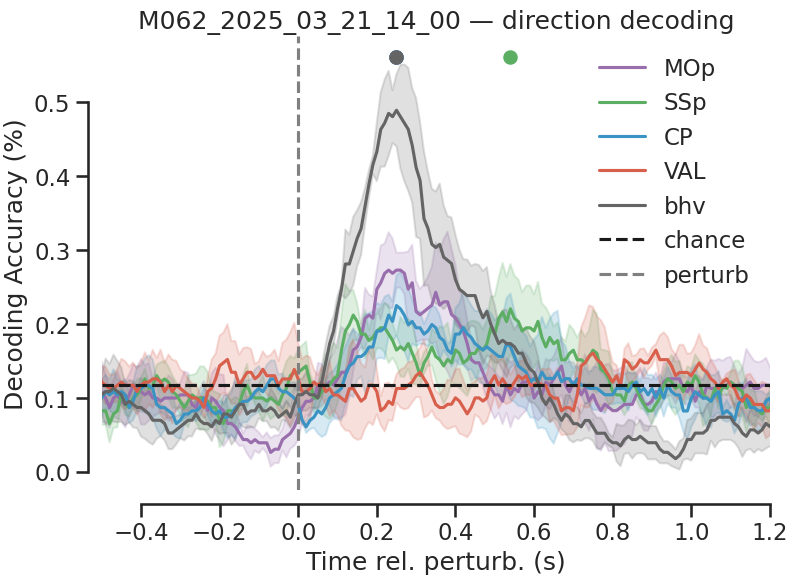


M078_2025_08_06_15_00


100%|██████████| 482/482 [00:10<00:00, 48.19it/s]


  MOp: done  (mean acc = 0.107)


100%|██████████| 482/482 [00:10<00:00, 47.09it/s]


  SSp: done  (mean acc = 0.112)


...

  CP: done  (mean acc = 0.110)


100%|██████████| 482/482 [00:16<00:00, 29.24it/s]


  VAL: done  (mean acc = 0.110)


100%|██████████| 482/482 [00:06<00:00, 73.88it/s]


  bhv: done  (mean acc = 0.106)
  MOp     peak = +0.250 s   acc_max = 0.375   CoM = +0.343 s  (fold CoM: +0.373 ± 0.042 s)  rise = +0.130 s  (thresh = 0.161)
  SSp     peak = +0.240 s   acc_max = 0.284   CoM = +0.409 s  (fold CoM: +0.469 ± 0.142 s)  rise = +0.140 s  (thresh = 0.168)
  CP      peak = +0.230 s   acc_max = 0.203   CoM = +0.641 s  (fold CoM: +0.700 ± 0.354 s)  rise = +0.190 s  (thresh = 0.164)
  VAL     peak = +0.300 s   acc_max = 0.243   CoM = +0.743 s  (fold CoM: +0.808 ± 0.226 s)  rise = +0.190 s  (thresh = 0.163)
  bhv     peak = +0.240 s   acc_max = 0.301   CoM = +0.398 s  (fold CoM: +0.565 ± 0.072 s)  rise = +0.090 s  (thresh = 0.160)


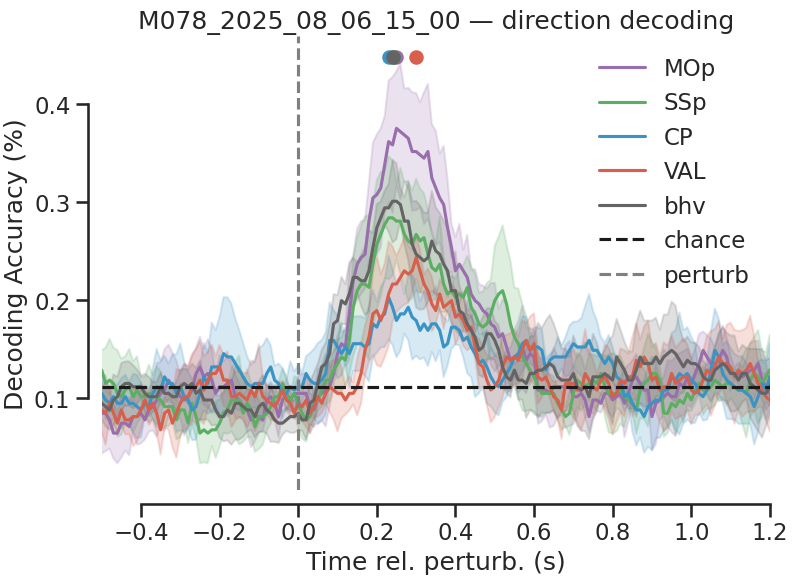


M086_2025_12_10_15_00


100%|██████████| 482/482 [00:16<00:00, 29.17it/s]


  MOp: done  (mean acc = 0.124)


100%|██████████| 482/482 [00:12<00:00, 37.78it/s]


  SSp: done  (mean acc = 0.152)


...

  CP: done  (mean acc = 0.140)


100%|██████████| 482/482 [00:08<00:00, 55.46it/s]


  VAL: done  (mean acc = 0.107)


100%|██████████| 482/482 [00:06<00:00, 76.32it/s]


  bhv: done  (mean acc = 0.139)
  MOp     peak = +0.310 s   acc_max = 0.338   CoM = +0.686 s  (fold CoM: +0.623 ± 0.288 s)  rise = +0.150 s  (thresh = 0.168)
  SSp     peak = +0.230 s   acc_max = 0.562   CoM = +0.560 s  (fold CoM: +0.545 ± 0.045 s)  rise = +0.090 s  (thresh = 0.172)
  CP      peak = +0.360 s   acc_max = 0.419   CoM = +0.577 s  (fold CoM: +0.602 ± 0.089 s)  rise = +0.120 s  (thresh = 0.165)
  VAL     peak = +0.500 s   acc_max = 0.165   CoM = +0.616 s  (fold CoM: +0.481 ± 0.351 s)  rise = nan  (thresh = 0.168)
  bhv     peak = +0.260 s   acc_max = 0.542   CoM = +0.462 s  (fold CoM: +0.495 ± 0.069 s)  rise = +0.080 s  (thresh = 0.163)


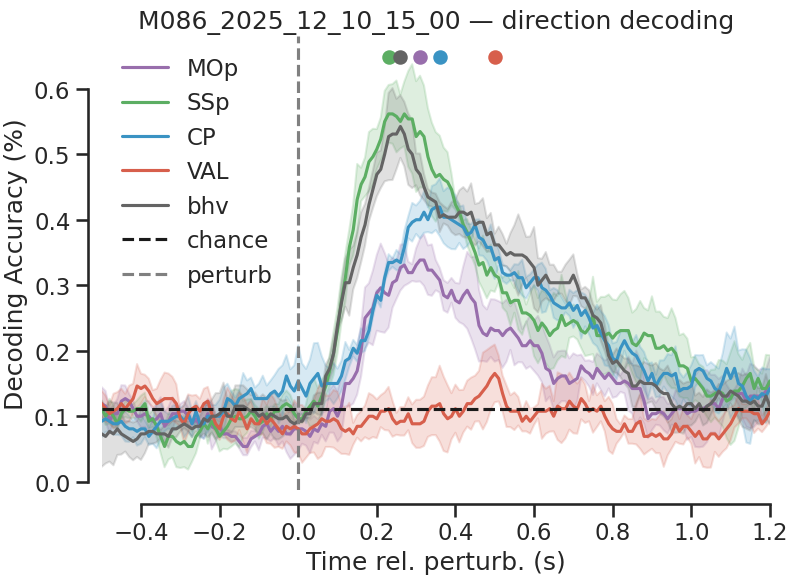


M103_2026_02_18_15_30


100%|██████████| 482/482 [00:15<00:00, 30.98it/s]


  MOp: done  (mean acc = 0.132)


100%|██████████| 482/482 [00:12<00:00, 38.90it/s]


  SSp: done  (mean acc = 0.123)


...

  CP: done  (mean acc = 0.130)


100%|██████████| 482/482 [00:16<00:00, 29.20it/s]


  VAL: done  (mean acc = 0.132)


100%|██████████| 482/482 [00:06<00:00, 73.99it/s]


  bhv: done  (mean acc = 0.104)
  MOp     peak = +0.220 s   acc_max = 0.485   CoM = +0.398 s  (fold CoM: +0.425 ± 0.074 s)  rise = +0.060 s  (thresh = 0.187)
  SSp     peak = +0.320 s   acc_max = 0.299   CoM = +0.377 s  (fold CoM: +0.487 ± 0.159 s)  rise = +0.110 s  (thresh = 0.178)
  CP      peak = +0.350 s   acc_max = 0.292   CoM = +0.716 s  (fold CoM: +0.683 ± 0.100 s)  rise = +0.160 s  (thresh = 0.180)
  VAL     peak = +0.260 s   acc_max = 0.282   CoM = +0.552 s  (fold CoM: +0.540 ± 0.183 s)  rise = +0.130 s  (thresh = 0.180)
  bhv     peak = +0.220 s   acc_max = 0.430   CoM = +0.282 s  (fold CoM: +0.340 ± 0.058 s)  rise = +0.090 s  (thresh = 0.167)


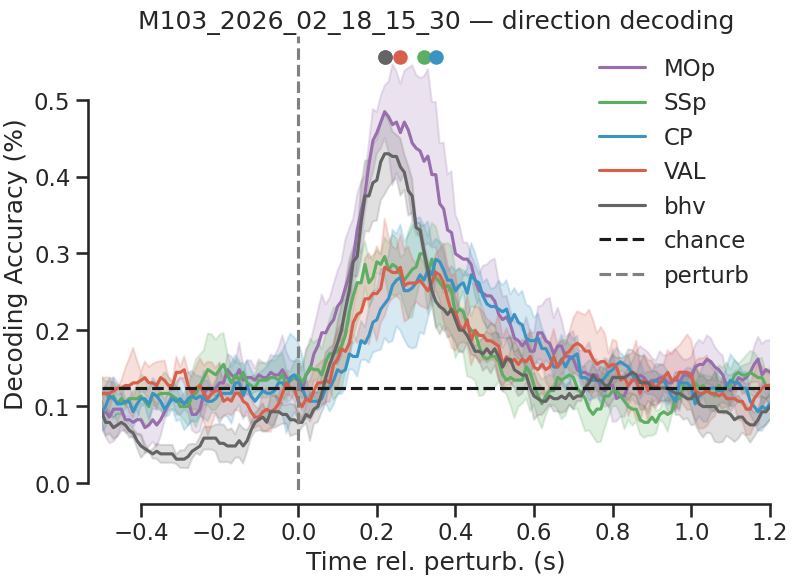


M106_2026_02_25_15_00


100%|██████████| 482/482 [00:11<00:00, 41.09it/s]


  MOp: done  (mean acc = 0.134)


100%|██████████| 482/482 [00:11<00:00, 43.59it/s]


  SSp: done  (mean acc = 0.144)


...

  CP: done  (mean acc = 0.157)


100%|██████████| 482/482 [00:10<00:00, 44.20it/s]


  VAL: done  (mean acc = 0.147)


100%|██████████| 482/482 [00:06<00:00, 78.67it/s]


  bhv: done  (mean acc = 0.096)
  MOp     peak = +0.220 s   acc_max = 0.417   CoM = +0.308 s  (fold CoM: +0.434 ± 0.149 s)  rise = +0.140 s  (thresh = 0.223)
  SSp     peak = +0.280 s   acc_max = 0.292   CoM = +0.290 s  (fold CoM: +0.231 ± 0.240 s)  rise = +0.170 s  (thresh = 0.227)
  CP      peak = +0.340 s   acc_max = 0.287   CoM = +0.414 s  (fold CoM: +0.433 ± 0.175 s)  rise = +0.210 s  (thresh = 0.221)
  VAL     peak = +0.230 s   acc_max = 0.292   CoM = +0.174 s  (fold CoM: +0.242 ± 0.159 s)  rise = +0.170 s  (thresh = 0.220)
  bhv     peak = +0.250 s   acc_max = 0.361   CoM = +0.256 s  (fold CoM: +0.258 ± 0.013 s)  rise = +0.150 s  (thresh = 0.221)


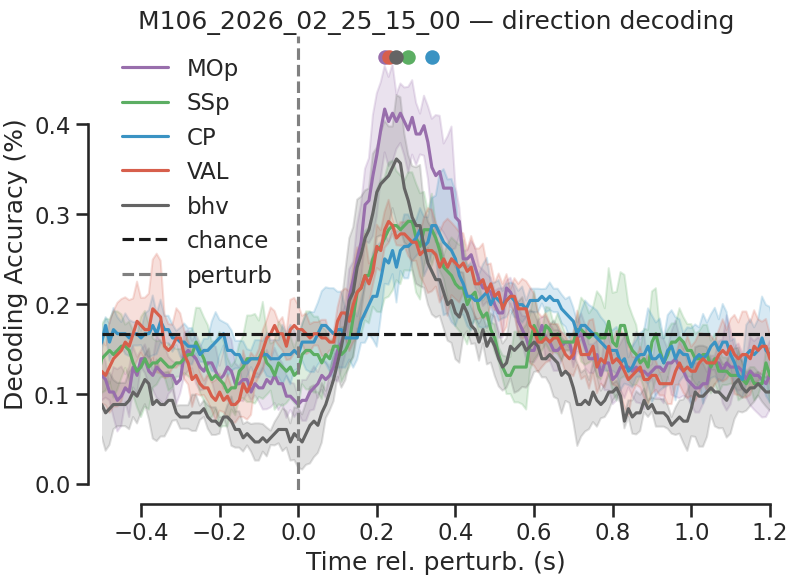


--- Summary ---
  M061_2025_03_04_10_00  →  MOp: acc_max=0.493  peak=+0.240s  CoM=+0.458s  post_max=0.493  SSp: acc_max=0.295  peak=+0.240s  CoM=+0.159s  post_max=0.295  CP: acc_max=0.392  peak=+0.270s  CoM=+0.533s  post_max=0.392  VAL: acc_max=0.323  peak=+0.320s  CoM=+0.155s  post_max=0.323  bhv: acc_max=0.539  peak=+0.260s  CoM=+0.331s  post_max=0.539
  M061_2025_03_05_14_00  →  MOp: acc_max=0.351  peak=+0.240s  CoM=+0.365s  post_max=0.351  SSp: acc_max=0.246  peak=+0.180s  CoM=+0.427s  post_max=0.246  CP: acc_max=0.377  peak=+0.290s  CoM=+0.218s  post_max=0.377  VAL: acc_max=0.227  peak=+0.280s  CoM=+0.456s  post_max=0.227  bhv: acc_max=0.344  peak=+0.240s  CoM=+0.198s  post_max=0.344
  M061_2025_03_06_14_00  →  MOp: acc_max=0.475  peak=+0.240s  CoM=+0.327s  post_max=0.475  SSp: acc_max=0.299  peak=+0.260s  CoM=+0.341s  post_max=0.299  CP: acc_max=0.362  peak=+0.300s  CoM=+0.584s  post_max=0.362  VAL: acc_max=0.290  peak=+0.310s  CoM=+0.415s  post_max=0.290  bhv: acc_max=0.421  pe

In [8]:

# --- Step 2: Decode each session + diagnostic plot ---
all_session_lags = {}  # {session: {area: {...}, '_chance': float} or None}

# for sess, proc in tqdm(all_session_processed.items(), desc="Decoding sessions"):
for sess in sessions:
    proc = all_session_processed[sess]
    if proc is None:
        all_session_lags[sess] = None
        continue
    print(f"\n{'='*60}\n{sess}\n{'='*60}")
    try:
        td       = proc['td']
        y_s = np.array(td.values_Sol_direction.values.tolist(), dtype=int)
        chance_s = np.max(np.bincount(y_s)) / len(y_s)

        results_s = decode_direction_by_area(td, AREAS, step=1, k=4, shuffle=True, rnd=42)
        lags_s    = compute_peak_lags(results_s, chance_s)

        # Diagnostic: time vs accuracy curves for this session
        with vizutils.apply_plot_style():
            fig, ax = plot_decoding_by_area(results_s, AREAS, chance=chance_s, peak_lags=lags_s)
            ax.set_xlim(-0.5, 1.2)
            ax.set_title(f"{sess} — direction decoding")
        plt.show()

        sess_entry = {'_chance': chance_s}
        for area, info in lags_s.items():
            res = results_s[area]
            times = res["times"] - TIME_OFFSET
            post_mask = (times >= 0) & (times <= 1.0)
            post_perturb_max = float(np.mean(res["scores"][post_mask], axis=1).max()) if post_mask.any() else 0.0
            sess_entry[area] = {
                'acc_max':         info['acc_max'],
                'peak':            info['peak'],
                'com_mean':        info['com_mean'],
                'post_perturb_max': post_perturb_max,
                'rise': info['rise']
            }
        all_session_lags[sess] = sess_entry

    except Exception as e:
        import traceback
        print(f"  ERROR decoding {sess}: {e}")
        traceback.print_exc()
        all_session_lags[sess] = None

print("\n--- Summary ---")
for s, lags in all_session_lags.items():
    if lags is not None:
        lag_str = "  ".join(
            f"{a}: acc_max={v['acc_max']:.3f}  peak={v['peak']:+.3f}s  CoM={v['com_mean']:+.3f}s  post_max={v['post_perturb_max']:.3f}"
            for a, v in lags.items() if not a.startswith('_')
        )
        print(f"  {s}  →  {lag_str}")
    else:
        print(f"  {s}  →  FAILED")


In [9]:

import copy

# Drop neural areas for M063 (keep bhv), drop VAL for M062 and M086
NEURAL_AREAS = ['MOp', 'SSp', 'CP', 'VAL']

all_session_lags_filt = {}
for sess, sess_lags in all_session_lags.items():
    if sess_lags is None:
        all_session_lags_filt[sess] = None
        continue
    entry = copy.deepcopy(sess_lags)
    if 'M062' in sess or 'M086' in sess:
        entry.pop('VAL', None)
        print(f"  {sess}  →  dropped VAL")
    # if sess == 'M062_2025_03_21_14_00':
    #     entry.pop('SSp', None)
    #     print(f"  {sess}  →  dropped SSp")
    all_session_lags_filt[sess] = entry


  M062_2025_03_20_14_00  →  dropped VAL
  M062_2025_03_21_14_00  →  dropped VAL
  M086_2025_12_10_15_00  →  dropped VAL


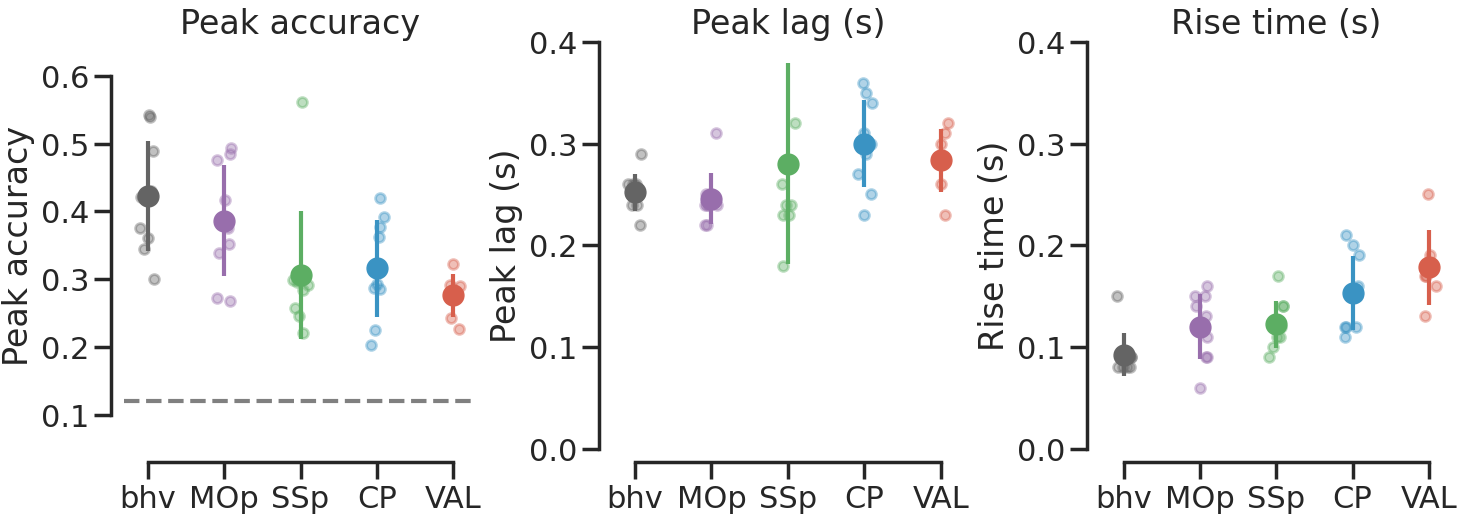

In [10]:
# --- Aggregate across sessions ---
metrics = ['acc_max', 'peak', 'rise']
metric_labels = ['Peak accuracy', 'Peak lag (s)', 'Rise time (s)']
PLOT_ORDER = ['bhv', 'MOp', 'SSp', 'CP', 'VAL']

# Fraction of the available range [chance, 1] that must be exceeded post-perturbation.
# e.g. 0.10 → area must decode at least 10% of the way from chance to perfect accuracy.
ABOVE_CHANCE_MARGIN = 0.1
JITTER = 0.1   # horizontal jitter width
chances = []
# Build {area: {metric: [(sess, val), ...]}} — keep session label for line drawing
agg = {area: {m: [] for m in metrics} for area in PLOT_ORDER}
for sess, sess_lags in all_session_lags_filt.items():
    if sess_lags is None:
        print(f"  {sess}  →  FAILED (skipping)")
        continue
    chance_sess = sess_lags.get('_chance', 0.0)
    chances.append(chance_sess)
    threshold = chance_sess + ABOVE_CHANCE_MARGIN * (1.0 - chance_sess)
    for area in PLOT_ORDER:
        if area not in sess_lags:
            continue
        post_max = sess_lags[area].get('post_perturb_max', 0.0)
        if post_max <= threshold:
            print(f"  DROPPED  {sess}  {area:6s}  post_max={post_max:.3f}  threshold={threshold:.3f}")
            continue
        for m in metrics:
            val = sess_lags[area][m]
            if m == 'peak' and val < 0:
                continue
            if m == 'rise' and (val is None or (isinstance(val, float) and np.isnan(val))):
                continue
            agg[area][m].append((sess, val))

rng_jitter = np.random.default_rng(0)
chances = np.array(chances)
# --- Plot ---
with vizutils.apply_plot_style('poster'):
    fig, axes = plt.subplots(1, 3, figsize=(15, 6))

    for ax, metric, ylabel in zip(axes, metrics, metric_labels):
        present = [a for a in PLOT_ORDER if len(agg[a][metric]) > 0]
        x_pos = np.arange(len(present))
        all_vals = np.concatenate([[v for _, v in agg[a][metric]] for a in present])
        vmin, vmax = np.nanmin(all_vals), np.nanmax(all_vals)
        pad = (vmax - vmin) * 0.15
        ax.set_ylim(vmin - pad, vmax + pad)

        # Store jittered positions per session for line drawing: {sess: {area: (x, y)}}
        sess_points = {}

        for i, area in enumerate(present):
            entries = agg[area][metric]   # [(sess, val), ...]
            vals = np.array([v for _, v in entries])
            mean = np.nanmean(vals)
            std  = np.nanstd(vals)
            c = getattr(colors, f'{area}_light', getattr(colors, area, 'steelblue'))
            jitter = rng_jitter.uniform(-JITTER, JITTER, size=len(vals))

            for (sess, val), jit in zip(entries, jitter):
                ax.scatter(i + jit, val, color=c, alpha=0.4, s=50, zorder=3)
                sess_points.setdefault(sess, {})[area] = (i + jit, val)

            ax.errorbar(i, mean, yerr=std, fmt='o', color=c,
                        capsize=0, capthick=2, ms=15, zorder=4)

        # Draw lines connecting same session across areas
        # for sess, area_pts in sess_points.items():
        #     xs = [area_pts[a][0] for a in present if a in area_pts]
        #     ys = [area_pts[a][1] for a in present if a in area_pts]
        #     if len(xs) > 1:
        #         ax.plot(xs, ys, color='grey', alpha=0.3, lw=1, zorder=2)

        ax.set_xticks(x_pos)
        ax.set_xticklabels(present, rotation=45, ha='right')
        ax.set_ylabel(ylabel)
        ax.set_title(ylabel)
        if ylabel == 'Peak lag (s)':
            ax.set_ylim(0.0, 0.4)
        elif ylabel == 'Rise time (s)':
            ax.set_ylim(0, 0.4)
        else:
            ax.axhline(chances.mean(), color='grey', linestyle='dashed')
            ax.set_ylim(0.05, 0.65)


    plt.tight_layout()
# fig.savefig("direction_decoding_summary.pdf")
plt.show()


In [47]:
from tools.viz.rc_style import rc_context_talk

metrics_2 = ["acc_max", "rise"]
metric_labels_2 = ["Peak accuracy", "Rise time (s)"]

with rc_context_talk():
    fig, axes = plt.subplots(1, 2, figsize=(5, 4))

    for ax, metric, ylabel in zip(axes, metrics_2, metric_labels_2):
        present = [a for a in PLOT_ORDER if len(agg[a][metric]) > 0]
        x_pos = np.arange(len(present))

        rng_jitter2 = np.random.default_rng(0)
        means = []

        for i, area in enumerate(present):
            entries = agg[area][metric]
            vals = np.array([v for _, v in entries])
            mean = np.nanmean(vals)
            std  = np.nanstd(vals)
            means.append((i, mean))
            c = getattr(colors, f"{area}_light", getattr(colors, f"{area}_light"))
            c_light = getattr(colors, f"{area}_light_light", getattr(colors, f"{area}_light_light"))
            jitter = rng_jitter2.uniform(-JITTER, JITTER, size=len(vals))

            for (sess, val), jit in zip(entries, jitter):
                ax.scatter(i + jit, val, color=c_light, alpha=1, s=20, zorder=3)

            ax.errorbar(i, mean, yerr=std, fmt="o", color=c,
                        capsize=0, capthick=2, ms=10, zorder=4)

        # Grey line connecting area means
        xs, ys = zip(*means)
        ax.plot(xs, ys, color="grey", lw=1.5, alpha=0.6, zorder=2)

        ax.set_xticks(x_pos)
        ax.set_xticklabels(present, rotation=45, ha="right")
        ax.set_ylabel(ylabel)
        # ax.set_title(ylabel)
        if metric == "rise":
            ax.set_ylim(0, 0.3)
        else:
            ax.axhline(chances.mean(), color="grey", linestyle="dashed")
            ax.set_ylim(0.05, 0.65)

    plt.tight_layout()
    plt.show()
    # fig.savefig('../../results/pdfs/timings_direction.svg', bbox_inches='tight')



NameError: name 'PLOT_ORDER' is not defined

In [12]:
# --- Example decoding curves for one session ---
example_sess = next(s for s, v in all_session_processed.items() if v is not None)
td_ex = all_session_processed[example_sess]["td"]
y_ex = np.array(td_ex.values_Sol_direction.values.tolist(), dtype=int)
chance_ex = np.max(np.bincount(y_ex)) / len(y_ex)

results_ex = decode_direction_by_area(td_ex, AREAS, step=1, k=4, shuffle=True, rnd=42)
lags_ex    = compute_peak_lags(results_ex, chance_ex)

print(f"Session: {example_sess}")
print(f"Chance: {chance_ex:.3f}")
for area, info in lags_ex.items():
    print(f"  {area}: acc_max={info['acc_max']:.3f}  peak={info['peak']:+.3f}s  rise={info['rise']}")

with rc_context_talk():
    fig, ax = plt.subplots(figsize=(7, 4))

    for area in AREAS:
        if area not in results_ex:
            continue
        scores = results_ex[area]["scores"]
        times  = results_ex[area]["times"] - TIME_OFFSET
        color  = getattr(colors, f"{area}_light", None)
        vizutils.shaded_errorbar(ax, times, scores, color=color, label=area)

    ax.axhline(chance_ex, color="k", linestyle="dashed", lw=1)
    ax.axvline(0, color="grey", linestyle="dashed", lw=1)

    ax.set_xlim(-0.5, 1.5)
    ax.set_xlabel("Time re. perturbation (s)")
    ax.set_ylabel("Decoding accuracy")
    ax.set_title(example_sess)
    ax.legend(frameon=False)
    plt.tight_layout()
    plt.show()


 15%|█▍        | 70/482 [00:02<00:14, 28.35it/s]


KeyboardInterrupt: 

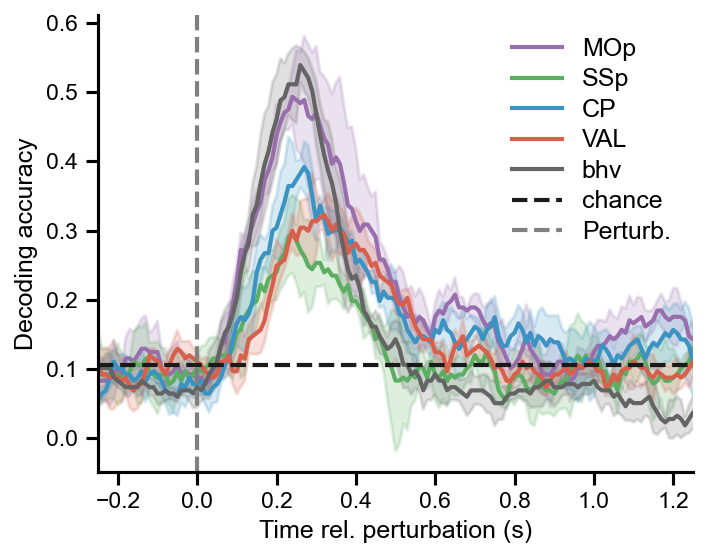

In [58]:
with rc_context_talk():
    fig, ax = plt.subplots(figsize=(5, 4))

    for area in AREAS:
        if area not in results_ex:
            continue
        scores = results_ex[area]["scores"]
        times  = results_ex[area]["times"] - TIME_OFFSET
        color  = getattr(colors, f"{area}_light", None)
        vizutils.shaded_errorbar(ax, times, scores, color=color, label=area)

    ax.axhline(chance_ex, color="k", linestyle="dashed", label='chance')
    ax.axvline(0, color="grey", linestyle="dashed", label='Perturb.')

    ax.set_xlim(-0.25, 1.25)
    ax.set_xlabel("Time rel. perturbation (s)")
    ax.set_ylabel("Decoding accuracy")
    fig.savefig('../../results/pdfs/example_direction.svg', bbox_inches='tight')

    # ax.set_title(example_sess)
    ax.legend(frameon=False)
    plt.tight_layout()
    plt.show()

In [53]:

# Summary: how many sessions contribute per area after filtering
print(f"{'Area':<8}  sessions kept")
for area in ['bhv', 'MOp', 'SSp', 'CP', 'VAL']:
    kept = [s for s, lags in all_session_lags_filt.items()
            if lags is not None and area in lags]
    print(f"  {area:<6}  {len(kept)}  {kept}")


Area      sessions kept
  bhv     9  ['M061_2025_03_04_10_00', 'M061_2025_03_05_14_00', 'M061_2025_03_06_14_00', 'M062_2025_03_20_14_00', 'M062_2025_03_21_14_00', 'M078_2025_08_06_15_00', 'M086_2025_12_10_15_00', 'M103_2026_02_18_15_30', 'M106_2026_02_25_15_00']
  MOp     9  ['M061_2025_03_04_10_00', 'M061_2025_03_05_14_00', 'M061_2025_03_06_14_00', 'M062_2025_03_20_14_00', 'M062_2025_03_21_14_00', 'M078_2025_08_06_15_00', 'M086_2025_12_10_15_00', 'M103_2026_02_18_15_30', 'M106_2026_02_25_15_00']
  SSp     8  ['M061_2025_03_04_10_00', 'M061_2025_03_05_14_00', 'M061_2025_03_06_14_00', 'M062_2025_03_20_14_00', 'M078_2025_08_06_15_00', 'M086_2025_12_10_15_00', 'M103_2026_02_18_15_30', 'M106_2026_02_25_15_00']
  CP      9  ['M061_2025_03_04_10_00', 'M061_2025_03_05_14_00', 'M061_2025_03_06_14_00', 'M062_2025_03_20_14_00', 'M062_2025_03_21_14_00', 'M078_2025_08_06_15_00', 'M086_2025_12_10_15_00', 'M103_2026_02_18_15_30', 'M106_2026_02_25_15_00']
  VAL     6  ['M061_2025_03_04_10_00', 'M061_

## Perturbation strength

In [3]:
sessions = [
    'M061_2025_03_04_10_00', 
    'M061_2025_03_05_14_00', 
    'M061_2025_03_06_14_00',
    # 'M063_2025_03_13_14_00',
    # 'M063_2025_03_14_15_30', 
    'M062_2025_03_20_14_00',
    'M062_2025_03_21_14_00',
    'M078_2025_08_06_15_00',
    'M086_2025_12_10_15_00',
    "M103_2026_02_18_15_30",
    "M106_2026_02_25_15_00",
]
all_session_processed = dsp.load_sessions_for_trial_analyses(sessions, std=0.03, std_dropping=True)

Loading sessions:   0%|          | 0/9 [00:00<?, ?it/s]


M061_2025_03_04_10_00
fields: ['values_before_camera_trigger', 'idx_before_camera_trigger'] could not be converted to int.
fields: ['idx_motion'] could not be converted to int.
fields: ['values_Sol_direction', 'idx_Sol_direction', 'values_Sol_duration', 'idx_Sol_duration', 'idx_sol_on'] could not be converted to int.
['all_spikes', 'VAL_spikes', 'SSp_spikes', 'GPe_spikes', 'MOp_spikes', 'CP_spikes']


/home/me24/repos/pyaldata/pyaldata/utils.py:155: UserWarning: values_MotSen1_X might be a time-varying field. It matches the length of all_spikes on 99.8529411764706% of trials
  warnings.warn(
/home/me24/repos/pyaldata/pyaldata/utils.py:155: UserWarning: idx_MotSen1_X might be a time-varying field. It matches the length of all_spikes on 99.8529411764706% of trials
  warnings.warn(
/home/me24/repos/pyaldata/pyaldata/utils.py:155: UserWarning: values_MotSen1_Y might be a time-varying field. It matches the length of all_spikes on 99.8529411764706% of trials
  warnings.warn(
/home/me24/repos/pyaldata/pyaldata/utils.py:155: UserWarning: idx_MotSen1_Y might be a time-varying field. It matches the length of all_spikes on 99.8529411764706% of trials
  warnings.warn(


Resulting all_spikes ephys data shape is (NxT): (53, 60000)
Resulting VAL_spikes ephys data shape is (NxT): (240, 60000)
Resulting SSp_spikes ephys data shape is (NxT): (59, 60000)
Resulting GPe_spikes ephys data shape is (NxT): (112, 60000)
Resulting MOp_spikes ephys data shape is (NxT): (206, 60000)
Resulting CP_spikes ephys data shape is (NxT): (225, 60000)
Skipped 54 trials
Otsu immobility threshold: 2.2328
Dropped 47 of 339 rows (13.86%).
Thresh val dropping -2
  drop_trials_sem_crosses_zero: by SEM: 179  |  by value: 265  |  kept: 179/265 (67.5%)


/home/me24/repos/earthquake-analysis/notebooks/standardising/../../tools/dsp/preprocessing.py:193: RuntimeWarning: divide by zero encountered in log10
  lambda a: np.log10(np.abs(np.sum(a)))
Loading sessions:  11%|█         | 1/9 [00:52<06:57, 52.13s/it]

...


M106_2026_02_25_15_00
fields: ['values_before_camera_trigger', 'idx_before_camera_trigger', 'values_Sol_duration', 'values_Sol_direction'] could not be converted to int.
fields: ['values_before_camera_trigger', 'values_Sol_duration', 'idx_Sol_duration', 'values_Sol_direction', 'idx_Sol_direction', 'idx_sol_on'] could not be converted to int.
fields: ['values_before_camera_trigger', 'values_Sol_duration', 'idx_Sol_duration', 'values_Sol_direction', 'idx_Sol_direction', 'idx_sol_on'] could not be converted to int.
['CP_spikes', 'MOp_spikes', 'all_spikes', 'VAL_spikes', 'SSp_spikes']


/home/me24/repos/pyaldata/pyaldata/utils.py:155: UserWarning: values_MotSen1_X might be a time-varying field. It matches the length of CP_spikes on 99.9001996007984% of trials
  warnings.warn(
/home/me24/repos/pyaldata/pyaldata/utils.py:155: UserWarning: idx_MotSen1_X might be a time-varying field. It matches the length of CP_spikes on 99.9001996007984% of trials
  warnings.warn(
/home/me24/repos/pyaldata/pyaldata/utils.py:155: UserWarning: values_MotSen1_Y might be a time-varying field. It matches the length of CP_spikes on 99.9001996007984% of trials
  warnings.warn(
/home/me24/repos/pyaldata/pyaldata/utils.py:155: UserWarning: idx_MotSen1_Y might be a time-varying field. It matches the length of CP_spikes on 99.9001996007984% of trials
  warnings.warn(


Resulting CP_spikes ephys data shape is (NxT): (206, 48000)
Resulting MOp_spikes ephys data shape is (NxT): (156, 48000)
Resulting all_spikes ephys data shape is (NxT): (11, 48000)
Resulting VAL_spikes ephys data shape is (NxT): (132, 48000)
Resulting SSp_spikes ephys data shape is (NxT): (142, 48000)
add_concat_perturb_time: dropping 1 trial(s) with missing idx_sol_on
Skipped 87 trials
Otsu immobility threshold: 2.2123
Dropped 130 of 499 rows (26.05%).
Thresh val dropping -2
  drop_trials_sem_crosses_zero: by SEM: 186  |  by value: 319  |  kept: 180/325 (55.4%)


Loading sessions: 100%|██████████| 9/9 [05:57<00:00, 39.77s/it]


Loaded 9/9 sessions successfully.


In [129]:
td = all_session_processed['M103_2026_02_18_15_30']['td']

In [130]:
y = td.disturb_sum.values

In [11]:
from scipy.ndimage import uniform_filter1d

def regression_perturb_strength_avg_window(
    X: np.ndarray,
    y: np.ndarray,
    max_time_bin=None,
    step_bin=1,
    window_length_bin=20,
    # scorer=decode.get_custom_scorer(),
    scorer=make_scorer(r2_score),
    alpha=0.01,
    cv=5,
    bin_size=0.01,
    min_time_bin=0,
    smooth_bins=5,
    min_rise_bins=10,
    rise_chance=0.01,
    perturb_onset_s=0.0,
) -> tuple:
    """Run moving-window regression of neural activity on perturbation strength.

    Returns
    -------
    scores    : ndarray (time × cv_folds)
    times_s   : ndarray  time axis in seconds
    rise_time : float    first post-perturbation time where smoothed mean R²
                         exceeds rise_chance + 2*mean_fold_std for
                         min_rise_bins consecutive bins (nan if never reached)
    """
    r2_scores = []
    if max_time_bin is None:
        max_time_bin = X.shape[1]

    for t in tqdm(
        np.arange(min_time_bin, max_time_bin + 1 - window_length_bin, step=step_bin)
    ):
        X_ = X[:, t : t + window_length_bin, :]
        n_trials, n_time, _ = X_.shape
        r2 = cross_val_score(
            Ridge(alpha=alpha, solver="svd"),
            X_.mean(1),
            y,
            scoring=scorer,
            cv=cv,
        )
        r2_scores.append(r2)

    scores  = np.array(r2_scores)   # (time × cv_folds)
    times_s = np.arange(min_time_bin + window_length_bin, max_time_bin + 1, step_bin) * bin_size

    # --- Rise time ---
    mean_curve    = np.mean(scores, axis=1)
    # smoothed      = uniform_filter1d(mean_curve, size=smooth_bins)
    smoothed = mean_curve
    
    mean_fold_std = np.std(scores, axis=1).mean()
    rise_thresh   = rise_chance #+ 2 * mean_fold_std
    post_mask     = times_s >= perturb_onset_s
    above_thresh  = (smoothed > rise_thresh) & post_mask
    rise_time     = np.nan
    post_indices  = np.where(post_mask)[0]
    for t in post_indices[:max(0, len(post_indices) - min_rise_bins + 1)]:
        if np.all(above_thresh[t : t + min_rise_bins]):
            rise_time = float(times_s[t])
            break

    return scores, times_s, rise_time


Regressing sessions:   0%|          | 0/9 [00:00<?, ?it/s]


M061_2025_03_04_10_00


100%|██████████| 236/236 [00:01<00:00, 171.50it/s]


  MOp: rise=2.12


100%|██████████| 236/236 [00:01<00:00, 183.03it/s]


  SSp: rise=2.16


100%|██████████| 236/236 [00:01<00:00, 171.59it/s]


  CP: rise=2.16


100%|██████████| 236/236 [00:02<00:00, 82.16it/s]


  VAL: rise=2.22
  MOp     peak = +0.380 s   acc_max = 0.587   CoM = +0.644 s  (fold CoM: +0.656 ± 0.071 s)  rise = +0.160 s  (thresh = 0.237)
  SSp     peak = +0.440 s   acc_max = 0.332   CoM = +0.622 s  (fold CoM: +0.621 ± 0.141 s)  rise = +0.260 s  (thresh = 0.226)
  CP      peak = +0.360 s   acc_max = 0.480   CoM = +0.617 s  (fold CoM: +0.603 ± 0.113 s)  rise = +0.220 s  (thresh = 0.342)
  VAL     peak = +0.640 s   acc_max = 0.392   CoM = +0.678 s  (fold CoM: +0.750 ± 0.096 s)  rise = +0.560 s  (thresh = 0.374)


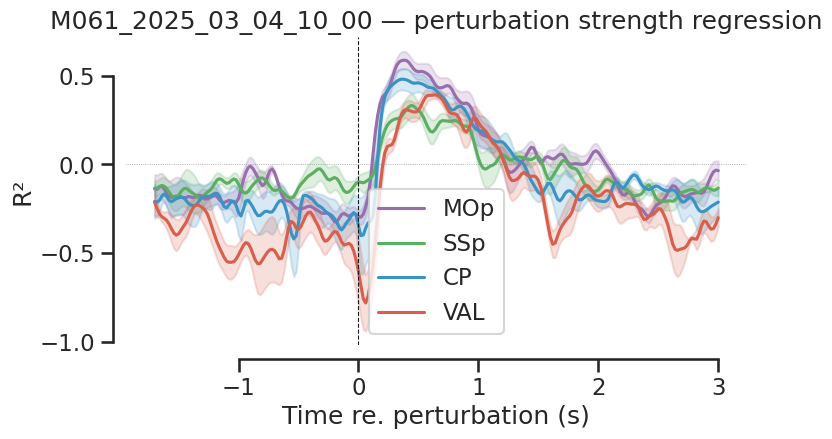

Regressing sessions:  11%|█         | 1/9 [00:07<00:56,  7.08s/it]


M061_2025_03_05_14_00


100%|██████████| 236/236 [00:01<00:00, 175.19it/s]


  MOp: rise=2.22


100%|██████████| 236/236 [00:01<00:00, 184.67it/s]


  SSp: rise=2.18


100%|██████████| 236/236 [00:01<00:00, 175.73it/s]


  CP: rise=2.22


100%|██████████| 236/236 [00:02<00:00, 92.73it/s]


  VAL: rise=nan
  MOp     peak = +0.640 s   acc_max = 0.324   CoM = +0.546 s  (fold CoM: +0.574 ± 0.043 s)  rise = nan  (thresh = 0.412)
  SSp     peak = +0.560 s   acc_max = 0.193   CoM = +0.588 s  (fold CoM: +0.646 ± 0.292 s)  rise = nan  (thresh = 0.344)
  CP      peak = +0.540 s   acc_max = 0.304   CoM = +0.638 s  (fold CoM: +0.643 ± 0.098 s)  rise = nan  (thresh = 0.436)
  VAL     peak = +0.500 s   acc_max = -0.017   CoM = +nan s  (fold CoM: +0.742 ± 0.817 s)  rise = nan  (thresh = 0.563)


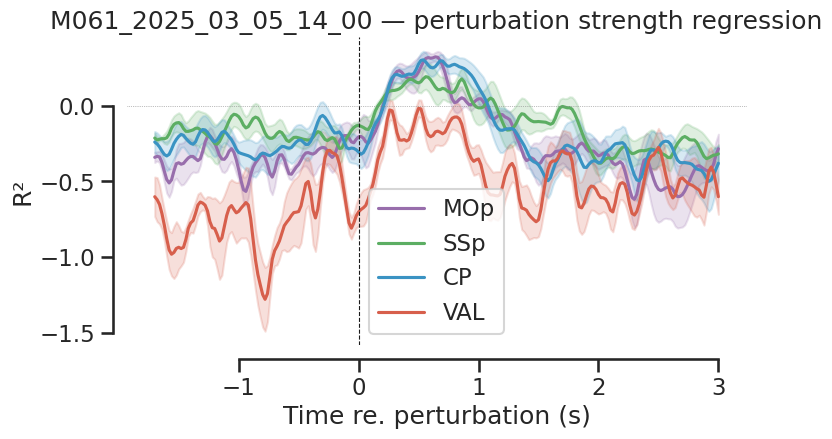

Regressing sessions:  22%|██▏       | 2/9 [00:13<00:47,  6.83s/it]


M061_2025_03_06_14_00


100%|██████████| 236/236 [00:01<00:00, 168.91it/s]


  MOp: rise=2.18


100%|██████████| 236/236 [00:01<00:00, 178.66it/s]


  SSp: rise=2.18


100%|██████████| 236/236 [00:01<00:00, 170.51it/s]


  CP: rise=2.2600000000000002


100%|██████████| 236/236 [00:02<00:00, 79.22it/s]


  VAL: rise=2.24
  MOp     peak = +0.460 s   acc_max = 0.438   CoM = +0.690 s  (fold CoM: +0.731 ± 0.107 s)  rise = +0.260 s  (thresh = 0.289)
  SSp     peak = +0.500 s   acc_max = 0.343   CoM = +0.594 s  (fold CoM: +0.798 ± 0.179 s)  rise = +0.340 s  (thresh = 0.244)
  CP      peak = +0.680 s   acc_max = 0.360   CoM = +0.787 s  (fold CoM: +0.795 ± 0.133 s)  rise = +0.380 s  (thresh = 0.265)
  VAL     peak = +0.480 s   acc_max = 0.334   CoM = +0.653 s  (fold CoM: +0.680 ± 0.150 s)  rise = nan  (thresh = 0.424)


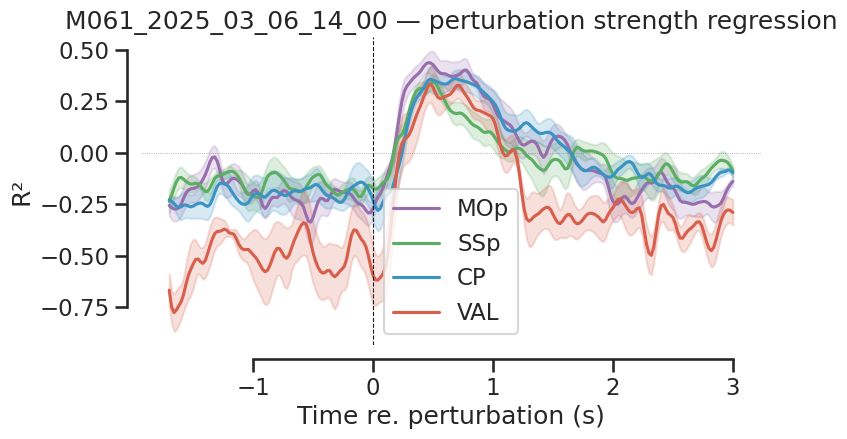

Regressing sessions:  33%|███▎      | 3/9 [00:20<00:42,  7.02s/it]


M062_2025_03_20_14_00


100%|██████████| 236/236 [00:01<00:00, 164.13it/s]


  MOp: rise=2.22


100%|██████████| 236/236 [00:01<00:00, 173.83it/s]


  SSp: rise=2.2


100%|██████████| 236/236 [00:01<00:00, 167.18it/s]


  CP: rise=2.1


100%|██████████| 236/236 [00:02<00:00, 91.30it/s]


  VAL: rise=2.66
  MOp     peak = +0.620 s   acc_max = 0.332   CoM = +0.731 s  (fold CoM: +0.739 ± 0.121 s)  rise = nan  (thresh = 0.345)
  SSp     peak = +0.620 s   acc_max = 0.260   CoM = +0.629 s  (fold CoM: +0.653 ± 0.185 s)  rise = +0.340 s  (thresh = 0.229)
  CP      peak = +0.520 s   acc_max = 0.457   CoM = +0.624 s  (fold CoM: +0.713 ± 0.124 s)  rise = +0.340 s  (thresh = 0.333)
  VAL     peak = +0.760 s   acc_max = 0.108   CoM = +0.764 s  (fold CoM: +0.941 ± 0.130 s)  rise = nan  (thresh = 0.477)


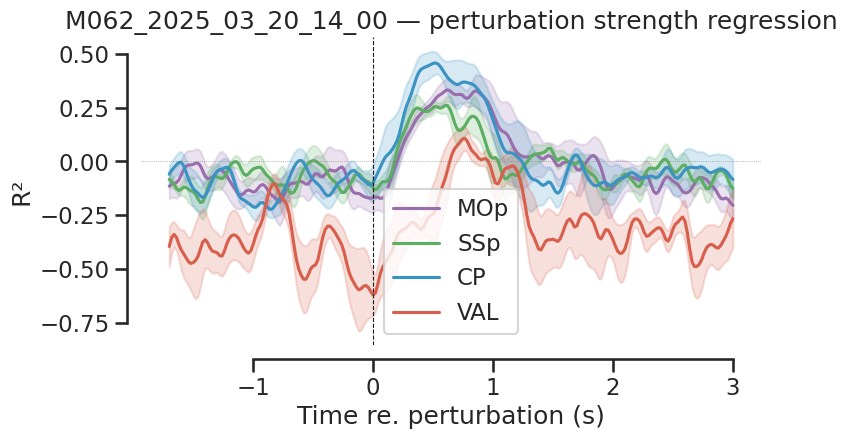

Regressing sessions:  44%|████▍     | 4/9 [00:27<00:34,  6.99s/it]


M062_2025_03_21_14_00


100%|██████████| 236/236 [00:01<00:00, 164.18it/s]


  MOp: rise=2.34


100%|██████████| 236/236 [00:01<00:00, 173.26it/s]


  SSp: rise=2.2800000000000002


100%|██████████| 236/236 [00:01<00:00, 165.85it/s]


  CP: rise=2.2600000000000002


100%|██████████| 236/236 [00:02<00:00, 87.59it/s]


  VAL: rise=nan
  MOp     peak = +0.560 s   acc_max = 0.218   CoM = +0.807 s  (fold CoM: +0.915 ± 0.140 s)  rise = nan  (thresh = 0.219)
  SSp     peak = +0.440 s   acc_max = 0.168   CoM = +0.534 s  (fold CoM: +0.692 ± 0.206 s)  rise = nan  (thresh = 0.217)
  CP      peak = +0.440 s   acc_max = 0.260   CoM = +0.619 s  (fold CoM: +0.660 ± 0.110 s)  rise = nan  (thresh = 0.323)
  VAL     peak = +1.180 s   acc_max = 0.048   CoM = +1.151 s  (fold CoM: +1.228 ± 0.428 s)  rise = nan  (thresh = 0.417)


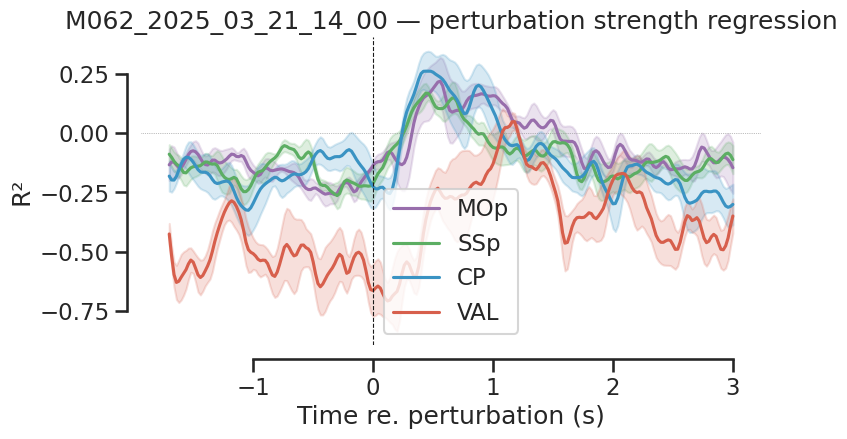

Regressing sessions:  56%|█████▌    | 5/9 [00:35<00:28,  7.02s/it]


M078_2025_08_06_15_00


100%|██████████| 236/236 [00:01<00:00, 160.79it/s]


  MOp: rise=2.12


100%|██████████| 236/236 [00:01<00:00, 169.36it/s]


  SSp: rise=2.16


100%|██████████| 236/236 [00:01<00:00, 159.55it/s]


  CP: rise=2.14


100%|██████████| 236/236 [00:03<00:00, 69.79it/s]


  VAL: rise=2.2600000000000002
  MOp     peak = +0.500 s   acc_max = 0.503   CoM = +0.656 s  (fold CoM: +0.598 ± 0.211 s)  rise = +0.180 s  (thresh = 0.225)
  SSp     peak = +0.540 s   acc_max = 0.430   CoM = +0.772 s  (fold CoM: +0.786 ± 0.064 s)  rise = +0.220 s  (thresh = 0.154)
  CP      peak = +0.580 s   acc_max = 0.467   CoM = +0.655 s  (fold CoM: +0.647 ± 0.057 s)  rise = +0.240 s  (thresh = 0.207)
  VAL     peak = +0.600 s   acc_max = 0.358   CoM = +0.779 s  (fold CoM: +0.816 ± 0.087 s)  rise = +0.420 s  (thresh = 0.260)


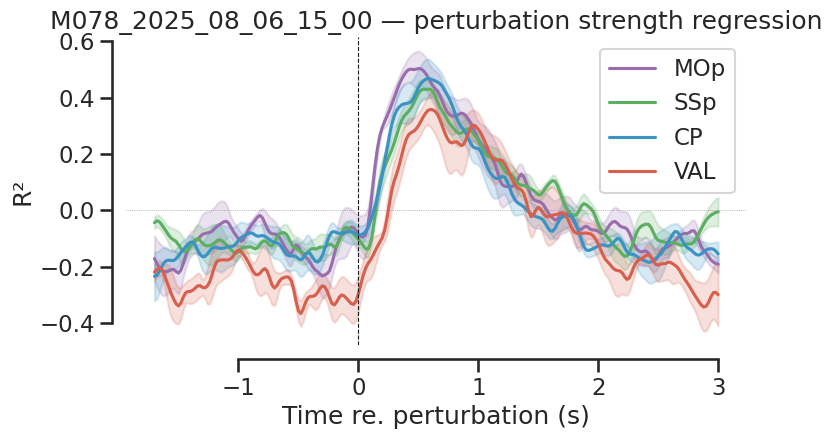

Regressing sessions:  67%|██████▋   | 6/9 [00:42<00:21,  7.31s/it]


M086_2025_12_10_15_00


100%|██████████| 236/236 [00:01<00:00, 158.44it/s]


  MOp: rise=2.2600000000000002


100%|██████████| 236/236 [00:01<00:00, 174.25it/s]


  SSp: rise=2.14


100%|██████████| 236/236 [00:01<00:00, 164.31it/s]


  CP: rise=2.22


100%|██████████| 236/236 [00:02<00:00, 82.10it/s]


  VAL: rise=nan
  MOp     peak = +0.380 s   acc_max = 0.203   CoM = +0.493 s  (fold CoM: +0.609 ± 0.225 s)  rise = nan  (thresh = 0.247)
  SSp     peak = +0.280 s   acc_max = 0.327   CoM = +0.718 s  (fold CoM: +0.856 ± 0.164 s)  rise = +0.220 s  (thresh = 0.254)
  CP      peak = +0.340 s   acc_max = 0.262   CoM = +0.476 s  (fold CoM: +0.580 ± 0.103 s)  rise = nan  (thresh = 0.339)
  VAL     peak = -0.060 s   acc_max = -0.251   CoM = +nan s  (fold CoM: +1.407 ± 0.716 s)  rise = nan  (thresh = 0.431)


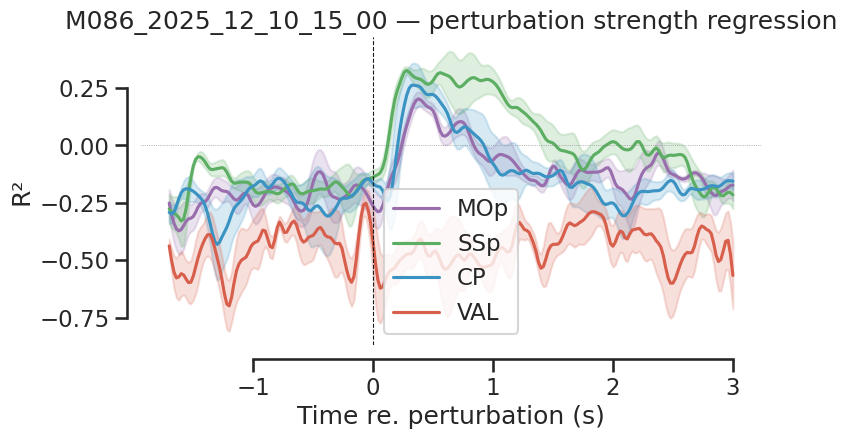

Regressing sessions:  78%|███████▊  | 7/9 [00:50<00:14,  7.32s/it]


M103_2026_02_18_15_30


100%|██████████| 236/236 [00:01<00:00, 161.10it/s]


  MOp: rise=2.12


100%|██████████| 236/236 [00:01<00:00, 168.90it/s]


  SSp: rise=2.14


100%|██████████| 236/236 [00:01<00:00, 161.06it/s]


  CP: rise=2.22


100%|██████████| 236/236 [00:02<00:00, 80.67it/s]


  VAL: rise=2.24
  MOp     peak = +0.460 s   acc_max = 0.447   CoM = +0.535 s  (fold CoM: +0.576 ± 0.120 s)  rise = +0.180 s  (thresh = 0.236)
  SSp     peak = +0.380 s   acc_max = 0.393   CoM = +0.416 s  (fold CoM: +0.559 ± 0.136 s)  rise = +0.200 s  (thresh = 0.184)
  CP      peak = +0.580 s   acc_max = 0.254   CoM = +0.647 s  (fold CoM: +0.815 ± 0.275 s)  rise = nan  (thresh = 0.266)
  VAL     peak = +0.420 s   acc_max = 0.257   CoM = +0.547 s  (fold CoM: +0.589 ± 0.071 s)  rise = nan  (thresh = 0.264)


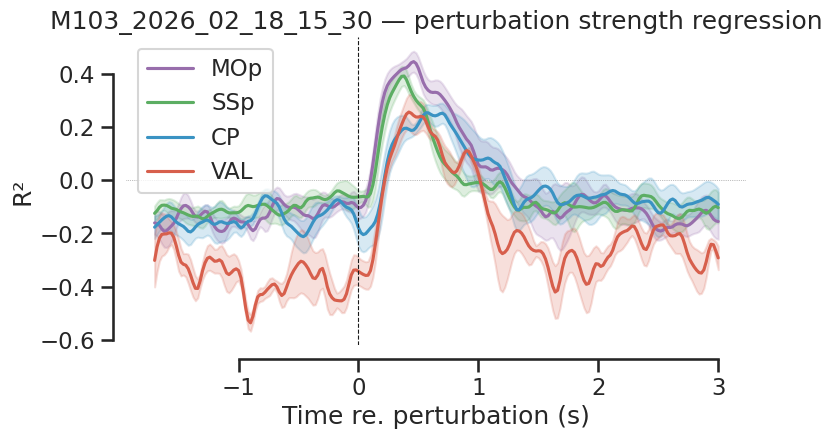

Regressing sessions:  89%|████████▉ | 8/9 [00:57<00:07,  7.35s/it]


M106_2026_02_25_15_00


100%|██████████| 236/236 [00:01<00:00, 166.25it/s]


  MOp: rise=2.1


100%|██████████| 236/236 [00:01<00:00, 174.09it/s]


  SSp: rise=2.14


100%|██████████| 236/236 [00:01<00:00, 167.22it/s]


  CP: rise=2.16


100%|██████████| 236/236 [00:02<00:00, 92.90it/s]


  VAL: rise=2.36
  MOp     peak = +0.460 s   acc_max = 0.356   CoM = +0.585 s  (fold CoM: +0.529 ± 0.299 s)  rise = nan  (thresh = 0.351)
  SSp     peak = +0.600 s   acc_max = 0.241   CoM = +0.691 s  (fold CoM: +0.807 ± 0.310 s)  rise = nan  (thresh = 0.325)
  CP      peak = +0.580 s   acc_max = 0.141   CoM = +0.700 s  (fold CoM: +0.665 ± 0.194 s)  rise = nan  (thresh = 0.292)
  VAL     peak = +0.520 s   acc_max = 0.188   CoM = +0.660 s  (fold CoM: +0.707 ± 0.218 s)  rise = nan  (thresh = 0.408)


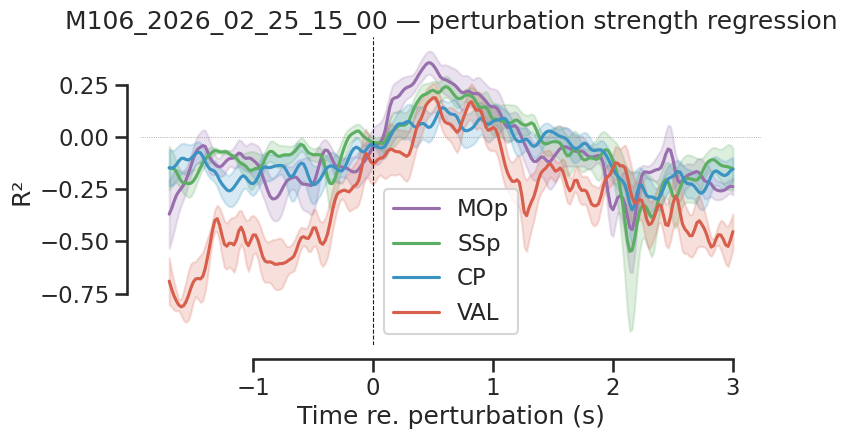

Regressing sessions: 100%|██████████| 9/9 [01:04<00:00,  7.17s/it]


--- Summary ---
  M061_2025_03_04_10_00  ->  MOp: r2_max=0.587  peak=+0.380s  post_max=0.587  rise=2.12  SSp: r2_max=0.332  peak=+0.440s  post_max=0.332  rise=2.16  CP: r2_max=0.480  peak=+0.360s  post_max=0.480  rise=2.16  VAL: r2_max=0.392  peak=+0.640s  post_max=0.392  rise=2.22
  M061_2025_03_05_14_00  ->  MOp: r2_max=0.324  peak=+0.640s  post_max=0.324  rise=2.22  SSp: r2_max=0.193  peak=+0.560s  post_max=0.193  rise=2.18  CP: r2_max=0.304  peak=+0.540s  post_max=0.304  rise=2.22  VAL: r2_max=-0.017  peak=+0.500s  post_max=-0.017  rise=nan
  M061_2025_03_06_14_00  ->  MOp: r2_max=0.438  peak=+0.460s  post_max=0.438  rise=2.18  SSp: r2_max=0.343  peak=+0.500s  post_max=0.343  rise=2.18  CP: r2_max=0.360  peak=+0.680s  post_max=0.360  rise=2.2600000000000002  VAL: r2_max=0.334  peak=+0.480s  post_max=0.334  rise=2.24
  M062_2025_03_20_14_00  ->  MOp: r2_max=0.332  peak=+0.620s  post_max=0.332  rise=2.22  SSp: r2_max=0.260  peak=+0.620s  post_max=0.260  rise=2.2  CP: r2_max=0.457  p

In [12]:
# --- Perturbation strength regression: per session, per area ---
AREAS_STR = ['MOp', 'SSp', 'CP', 'VAL']
WINDOW_LENGTH_BIN = 30   # 200 ms — chosen from sweep
STEP_BIN = 2

pc_dict = {
    "MOp": 25,
    "SSp": 20,
    "CP": 25,
    "VAL": 50
}

all_session_r2 = {}  # {session: {area: {...}, '_r2_baseline': 0.0} or None}

for sess, proc in tqdm(all_session_processed.items(), desc="Regressing sessions"):
    if proc is None:
        all_session_r2[sess] = None
        continue
    print(f"\n{'='*60}\n{sess}\n{'='*60}")
    try:
        td  = proc['td']
        y_s = td.disturb_sum.values

        sess_entry = {'_r2_baseline': 0.0}
        results_s  = {}

        for area in AREAS_STR:
            signal = f'{area}_rates_pca'
            if signal not in td.columns:
                print(f'  {area}: no PCA signal, skipping')
                continue
            X = np.stack(td[signal].values)[:, :, :pc_dict[area]]
            r2s, times, rise_s = regression_perturb_strength_avg_window(
                X, y_s,
                window_length_bin=WINDOW_LENGTH_BIN,
                cv=KFold(n_splits=5, shuffle=True, random_state=42),
                step_bin=STEP_BIN,
                alpha=0.01,
            )
            results_s[area] = {'scores': r2s, 'times': times, 'rise': rise_s}
            print(f'  {area}: rise={rise_s}')

        lags_s = compute_peak_lags(results_s, chance=0.0)

        # Diagnostic: R² curves per area for this session
        present = [a for a in AREAS_STR if a in results_s]
        with vizutils.apply_plot_style():
            fig, ax = plt.subplots(figsize=(8, 4))
            for area in present:
                res = results_s[area]
                t   = res['times'] - TIME_OFFSET
                mean_curve = np.mean(res['scores'], axis=1)
                sem_curve  = np.std(res['scores'], axis=1) / np.sqrt(res['scores'].shape[1])
                c = getattr(colors, f'{area}_light', getattr(colors, area, 'steelblue'))
                ax.plot(t, mean_curve, color=c, label=area)
                ax.fill_between(t, mean_curve - sem_curve, mean_curve + sem_curve, color=c, alpha=0.2)
            ax.axvline(0, color='k', lw=0.8, linestyle='--')
            ax.axhline(0, color='grey', lw=0.5, linestyle=':')
            ax.set_xlabel('Time re. perturbation (s)')
            ax.set_ylabel('R²')
            ax.set_title(f'{sess} — perturbation strength regression')
            ax.legend()
        plt.show()

        for area, info in lags_s.items():
            res           = results_s[area]
            times_shifted = res['times'] - TIME_OFFSET
            post_mask     = (times_shifted >= 0) & (times_shifted <= 1.0)
            post_max      = float(np.mean(res['scores'][post_mask], axis=1).max()) if post_mask.any() else 0.0
            sess_entry[area] = {
                'r2_max':           info['acc_max'],
                'peak':             info['peak'],
                'post_perturb_max': post_max,
                'rise':             results_s[area]['rise'],
            }
        all_session_r2[sess] = sess_entry

    except Exception as e:
        import traceback
        print(f"  ERROR: {e}")
        traceback.print_exc()
        all_session_r2[sess] = None

print("\n--- Summary ---")
for s, lags in all_session_r2.items():
    if lags is not None:
        lag_str = "  ".join(
            f"{a}: r2_max={v['r2_max']:.3f}  peak={v['peak']:+.3f}s  post_max={v['post_perturb_max']:.3f}  rise={v['rise']}"
            for a, v in lags.items() if not a.startswith('_')
        )
        print(f"  {s}  ->  {lag_str}")
    else:
        print(f"  {s}  ->  FAILED")

In [13]:
import copy

# Drop VAL for M062 and M086 (no VAL recording)
all_session_r2_filt = {}
for sess, sess_r2 in all_session_r2.items():
    if sess_r2 is None:
        all_session_r2_filt[sess] = None
        continue
    entry = copy.deepcopy(sess_r2)
    if 'M062' in sess or 'M086' in sess:
        entry.pop('VAL', None)
        print(f"  {sess}  ->  dropped VAL")
    # if sess == 'M061_2025_03_05_14_00':
    #     entry.pop('VAL', None)
    #     print(f"  {sess}  ->  dropped CP")
    all_session_r2_filt[sess] = entry

  M062_2025_03_20_14_00  ->  dropped VAL
  M062_2025_03_21_14_00  ->  dropped VAL
  M086_2025_12_10_15_00  ->  dropped VAL


In [13]:
# --- Example R² curves for one session ---
example_sess = next(s for s, v in all_session_r2_filt.items() if v is not None)
example_sess = 'M078_2025_08_06_15_00'
td_ex = all_session_processed[example_sess]['td']
y_ex  = td_ex.disturb_sum.values

results_ex = {}
for area in AREAS_STR:
    signal = f'{area}_rates_pca'
    if signal not in td_ex.columns:
        continue
    X = np.stack(td_ex[signal].values)[:, :, :pc_dict[area]]
    r2s, times, rise_s = regression_perturb_strength_avg_window(
        X, y_ex,
        window_length_bin=WINDOW_LENGTH_BIN,
        cv=KFold(n_splits=5, shuffle=True, random_state=42),
        step_bin=STEP_BIN,
        alpha=1,
    )
    results_ex[area] = {'scores': r2s, 'times': times, 'rise': rise_s}
    print(f'  {area}: rise={rise_s}')

  7%|▋         | 16/236 [00:00<00:01, 156.11it/s]

100%|██████████| 236/236 [00:01<00:00, 162.36it/s]


  MOp: rise=2.12


100%|██████████| 236/236 [00:01<00:00, 175.17it/s]


  SSp: rise=2.16


100%|██████████| 236/236 [00:01<00:00, 165.75it/s]


  CP: rise=2.14


100%|██████████| 236/236 [00:02<00:00, 79.51it/s]

  VAL: rise=2.2600000000000002


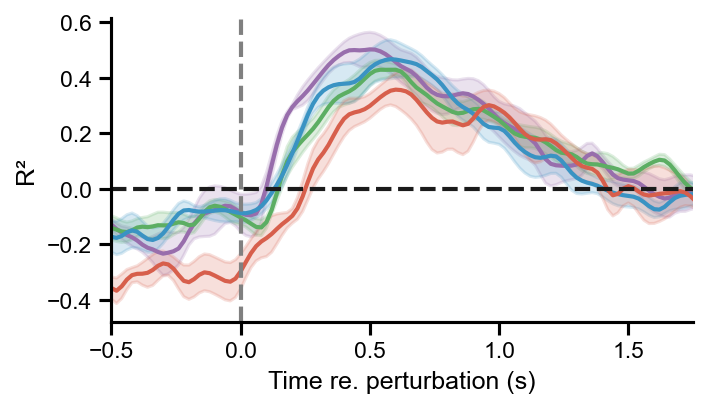

In [16]:
with rc_context_talk():
    fig, ax = plt.subplots(figsize=(5, 3))

    for area in AREAS_STR:
        if area not in results_ex:
            continue
        res        = results_ex[area]
        t          = res['times'] - TIME_OFFSET
        mean_curve = np.mean(res['scores'], axis=1)
        sem_curve  = np.std(res['scores'], axis=1) / np.sqrt(res['scores'].shape[1])
        c = getattr(colors, f'{area}_light', getattr(colors, area, 'steelblue'))
        ax.plot(t, mean_curve, color=c, label=area)
        ax.fill_between(t, mean_curve - sem_curve, mean_curve + sem_curve, color=c, alpha=0.2)

    ax.axvline(0, color='grey', linestyle='--')
    ax.axhline(0, color='k', linestyle='--')

    ax.set_xlim(-0.5, 1.75)
    ax.set_xlabel('Time re. perturbation (s)')
    ax.set_ylabel('R²')
    # ax.set_title(example_sess)
    # ax.legend(frameon=False)
    plt.tight_layout()
    plt.show()

  DROPPED  M061_2025_03_05_14_00  VAL     post_max=-0.017


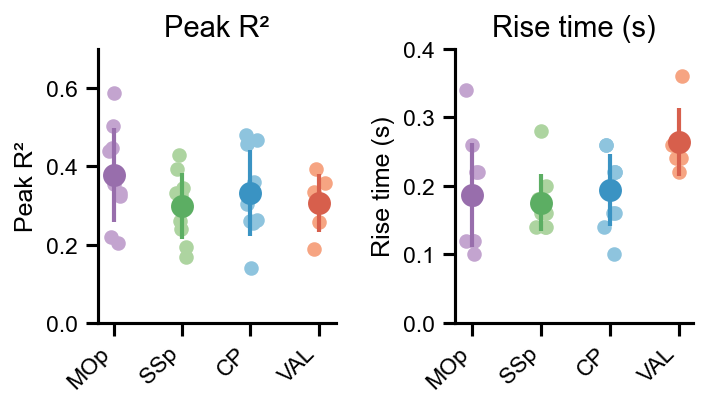

In [14]:
# --- Aggregate R² results across sessions ---
metrics_r2    = ['r2_max', 'rise']
labels_r2     = ['Peak R²', 'Rise time (s)']
PLOT_ORDER_R2 = ['MOp', 'SSp', 'CP', 'VAL']
MIN_POST_MAX  = 0.02   # drop area/session if post-perturb R² below this
JITTER = 0.1   # horizontal jitter width

agg_r2 = {area: {m: [] for m in metrics_r2} for area in PLOT_ORDER_R2}

for sess, sess_r2 in all_session_r2_filt.items():
    if sess_r2 is None:
        continue
    for area in PLOT_ORDER_R2:
        if area not in sess_r2:
            continue
        if sess_r2[area]['post_perturb_max'] < MIN_POST_MAX:
            print(f"  DROPPED  {sess}  {area:6s}  post_max={sess_r2[area]['post_perturb_max']:.3f}")
            continue
        for m in metrics_r2:
            val = sess_r2[area][m]
            if m == 'rise' and (val is None or (isinstance(val, float) and np.isnan(val))):
                continue
            agg_r2[area][m].append((sess, val - TIME_OFFSET if m == 'rise' else val))

rng_jitter_r2 = np.random.default_rng(1)

with rc_context_talk():
    fig, axes = plt.subplots(1, 2, figsize=(5, 3))

    for ax, metric, ylabel in zip(axes, metrics_r2, labels_r2):
        present = [a for a in PLOT_ORDER_R2 if len(agg_r2[a][metric]) > 0]
        x_pos   = np.arange(len(present))
        all_vals = np.concatenate([[v for _, v in agg_r2[a][metric]] for a in present])
        vmin, vmax = np.nanmin(all_vals), np.nanmax(all_vals)
        pad = (vmax - vmin) * 0.15

        sess_points = {}

        for i, area in enumerate(present):
            entries = agg_r2[area][metric]
            vals    = np.array([v for _, v in entries])
            mean    = np.nanmean(vals)
            std     = np.nanstd(vals)
            c       = getattr(colors, f'{area}_light', getattr(colors, area, 'steelblue'))
            c_light       = getattr(colors, f'{area}_light_light', getattr(colors, area, 'steelblue'))
            jitter  = rng_jitter_r2.uniform(-JITTER, JITTER, size=len(vals))

            for (sess, val), jit in zip(entries, jitter):
                ax.scatter(i + jit, val, color=c_light, alpha=1, s=30, zorder=3)
                sess_points.setdefault(sess, {})[area] = (i + jit, val)

            ax.errorbar(i, mean, yerr=std, fmt='o', color=c,
                        capsize=0, capthick=2, ms=10, zorder=4)

        ax.set_xticks(x_pos)
        ax.set_xticklabels(present, rotation=45, ha='right')
        ax.set_ylabel(ylabel)
        ax.set_title(ylabel)
        if metric == 'rise':
            ax.set_ylim(0, 0.4)
        else:
            # ax.axhline(0, color='grey', linestyle='dashed')
            ax.set_ylim(0, 0.7)

    plt.tight_layout()
    plt.show()

## Examples solenoid direction and disturbance

In [26]:
# --- Direction decoding ---
td_ex = all_session_processed['M103_2026_02_18_15_30']['td']

y_dir      = np.array(td_ex.values_Sol_direction.values.tolist(), dtype=int)
chance_dir = np.max(np.bincount(y_dir)) / len(y_dir)
dir_results = decode_direction_by_area(td_ex, AREAS, step=1, k=4, shuffle=True, rnd=42)
print(f"chance: {chance_dir:.3f}")

# --- Disturbance regression ---
y_dist = td_ex.disturb_sum.values
r2_results = {}
for area in AREAS_STR:
    signal = f'{area}_rates_pca'
    if signal not in td_ex.columns:
        continue
    X = np.stack(td_ex[signal].values)[:, :, :pc_dict[area]]
    r2s, times, rise_s = regression_perturb_strength_avg_window(
        X, y_dist,
        window_length_bin=WINDOW_LENGTH_BIN,
        cv=KFold(n_splits=5, shuffle=True, random_state=42),
        step_bin=1,
        # scorer=decode.get_custom_scorer(),
        alpha=1,
    )
    r2_results[area] = {'scores': r2s, 'times': times}
    print(f"  {area}: rise={rise_s:.3f}")



  0%|          | 0/482 [00:00<?, ?it/s]

100%|██████████| 482/482 [00:16<00:00, 28.44it/s]


  MOp: done  (mean acc = 0.132)


100%|██████████| 482/482 [00:13<00:00, 35.34it/s]


  SSp: done  (mean acc = 0.123)


...

  SSp: rise=2.140


100%|██████████| 472/472 [00:02<00:00, 165.16it/s]


  CP: rise=2.220


100%|██████████| 472/472 [00:06<00:00, 72.98it/s]

  VAL: rise=2.230


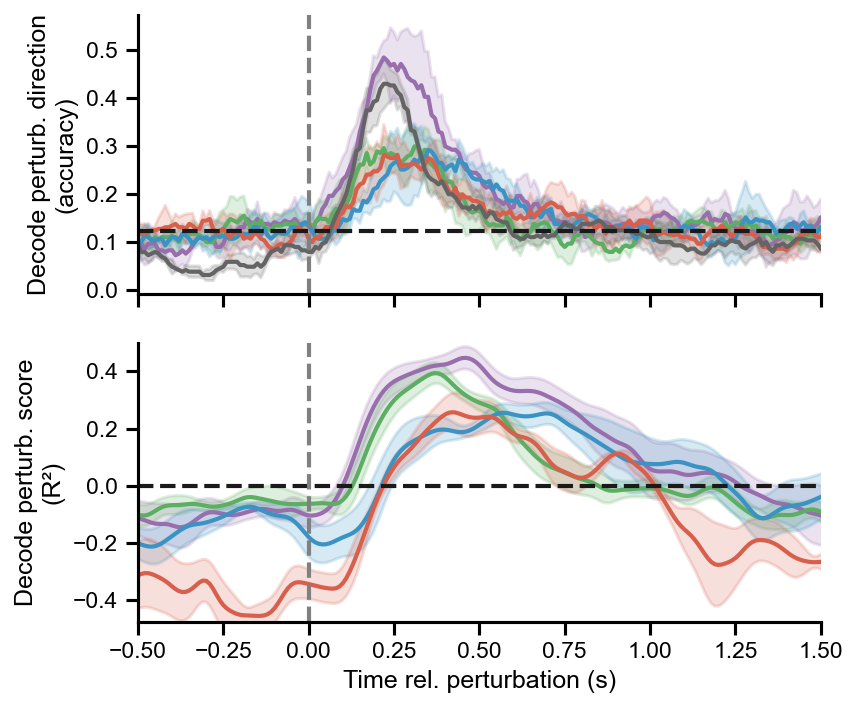

In [44]:
# --- Plot ---
with rc_context_talk():
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(6, 5), sharex=True)

    # Top: direction decoding
    for area in AREAS:
        if area not in dir_results:
            continue
        scores = dir_results[area]['scores']
        times  = dir_results[area]['times'] - TIME_OFFSET
        c = getattr(colors, f'{area}_light', None)
        vizutils.shaded_errorbar(ax1, times, scores, color=c, label=area)
    ax1.axhline(chance_dir, color='k', linestyle='dashed', )
    ax1.axvline(0, color='grey', linestyle='dashed', )
    ax1.set_xlim(-0.5, 1.5)
    ax1.set_ylabel('Decode perturb. direction\n(accuracy)')
    # ax1.set_title('Direction decoding')
    # ax1.legend(frameon=False)

    # Bottom: disturbance regression
    for area in AREAS_STR:
        if area not in r2_results:
            continue
        res        = r2_results[area]
        t          = res['times'] - TIME_OFFSET
        mean_curve = np.mean(res['scores'], axis=1)
        sem_curve  = np.std(res['scores'], axis=1) / np.sqrt(res['scores'].shape[1])
        c = getattr(colors, f'{area}_light', getattr(colors, area, 'steelblue'))
        ax2.plot(t, mean_curve, color=c, label=area)
        ax2.fill_between(t, mean_curve - sem_curve, mean_curve + sem_curve, color=c, alpha=0.2)
    ax2.axhline(0, color='k', linestyle='dashed')
    ax2.axvline(0, color='grey', linestyle='dashed')
    ax2.set_xlabel('Time rel. perturbation (s)')
    ax2.set_ylabel('Decode perturb. score\n(R²)')
    ax2.set_ylim(-0.475, 0.5)

    # ax2.set_title('Disturbance regression')
    # ax2.legend(frameon=False)

    plt.tight_layout()
    fig.savefig('../../results/pdfs/dist_dir_example_time.svg', bbox_inches='tight')

    plt.show()

Saved: ../../results/pdfs/dist_dir_red_dots.svg


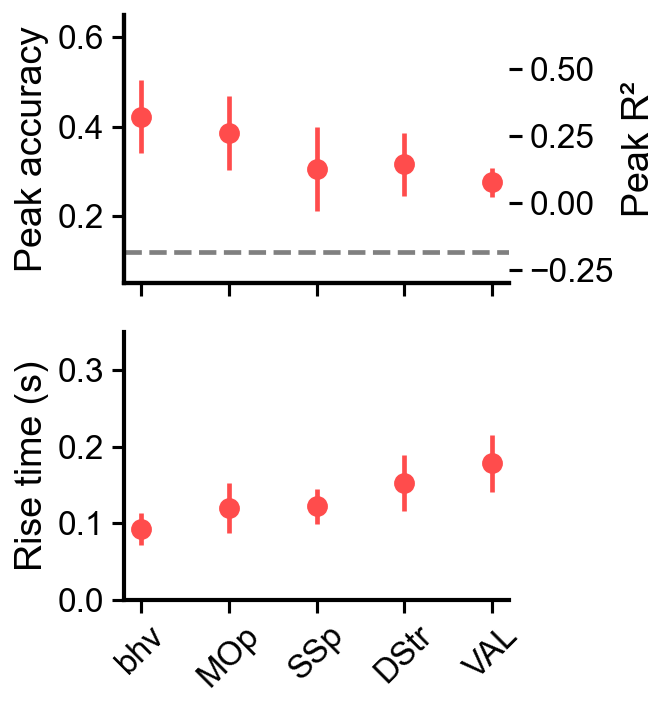

Saved: ../../results/pdfs/dist_dir_red_dots_lines.svg


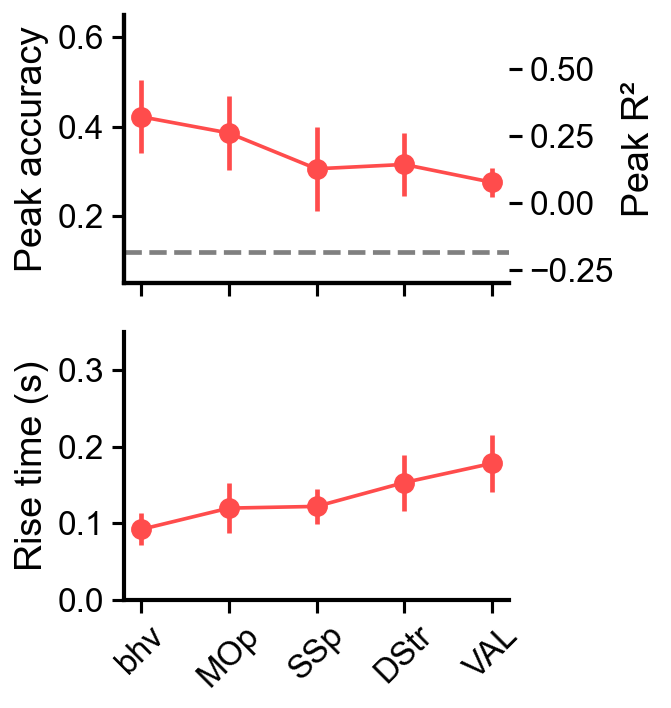

Saved: ../../results/pdfs/dist_dir_all.svg


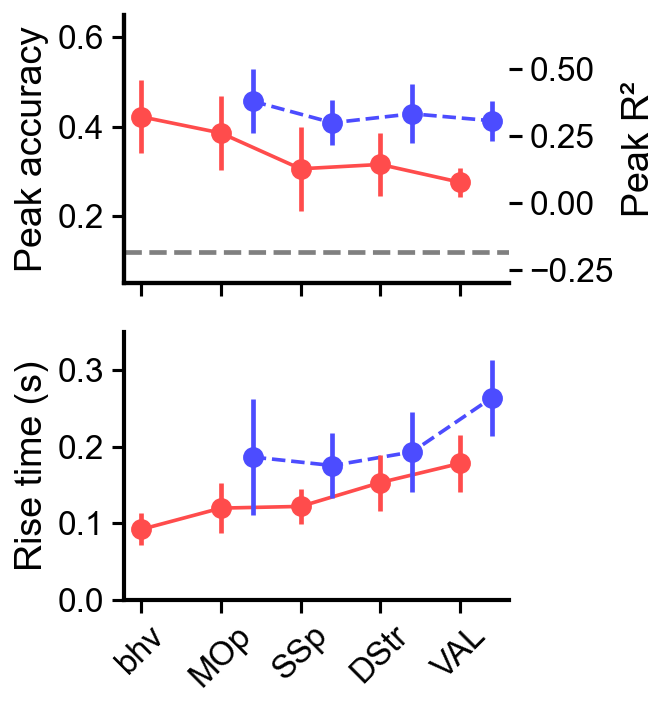

In [58]:
# --- Combined summary: direction decoding + disturbance regression ---
# Three saved variants:
#   1. red dots only, no lines
#   2. red dots + red lines
#   3. red + blue dots + both lines

from pathlib import Path
PLOT_ORDER_ALL = ['bhv', 'MOp', 'SSp', 'CP', 'VAL']
x_map         = {a: i for i, a in enumerate(PLOT_ORDER_ALL)}
DISP_LABELS   = {a: a for a in PLOT_ORDER_ALL}
DISP_LABELS['CP'] = 'DStr'
OFFSET = 0.4

bwr     = mpl.colormaps['bwr']
C_DIR   = bwr(0.85)
C_R2    = bwr(0.15)

_PDF_DIR = Path('../../results/pdfs')

from matplotlib.lines import Line2D
from tools.viz.rc_style import apply_rc_talk

apply_rc_talk()
def draw_figure(show_blue=False, show_lines=False):
        fig, (ax_top, ax_bot) = plt.subplots(2, 1, figsize=(4.5, 5), sharex=True)
        ax_top_r2 = ax_top.twinx()

        # ---- Top panel ----
        dir_means, r2_means = [], []
        for area in PLOT_ORDER_ALL:
            xi = x_map[area]

            entries = agg[area]['acc_max']
            if entries:
                vals = np.array([v for _, v in entries])
                mean, std = np.nanmean(vals), np.nanstd(vals)
                dir_means.append((xi, mean))
                ax_top.errorbar(xi, mean, yerr=std, fmt='o', color=C_DIR, capsize=0, ms=9, zorder=6)

            if show_blue and area in PLOT_ORDER_R2:
                entries_r2 = agg_r2[area]['r2_max']
                if entries_r2:
                    vals = np.array([v for _, v in entries_r2])
                    mean, std = np.nanmean(vals), np.nanstd(vals)
                    r2_means.append((xi + OFFSET, mean))
                    ax_top_r2.errorbar(xi + OFFSET, mean, yerr=std, fmt='o', color=C_R2, capsize=0, ms=9, zorder=6)

        if show_lines and dir_means:
            xs, ys = zip(*dir_means)
            ax_top.plot(xs, ys, color=C_DIR, lw=1.75, zorder=2)
        if show_lines and r2_means:
            xs, ys = zip(*r2_means)
            ax_top_r2.plot(xs, ys, color=C_R2, lw=1.75, ls='--', zorder=2)

        ax_top.axhline(chances.mean(), color='grey', ls='dashed')
        ax_top.set_xticks(range(len(PLOT_ORDER_ALL)))
        ax_top.set_xticklabels([DISP_LABELS[a] for a in PLOT_ORDER_ALL], rotation=45, ha='right')
        ax_top.set_ylabel('Peak accuracy')
        ax_top_r2.set_ylabel('Peak R²')
        ax_top.set_ylim(0.05, 0.65)
        ax_top_r2.set_ylim(-0.3, 0.7)

        # ---- Bottom panel ----
        dir_rise_means, r2_rise_means = [], []
        for area in PLOT_ORDER_ALL:
            xi = x_map[area]

            entries = agg[area]['rise']
            if entries:
                vals = np.array([v for _, v in entries])
                mean, std = np.nanmean(vals), np.nanstd(vals)
                dir_rise_means.append((xi, mean))
                ax_bot.errorbar(xi, mean, yerr=std, fmt='o', color=C_DIR, capsize=0, ms=9, zorder=6)

            if show_blue and area in PLOT_ORDER_R2:
                entries_r2 = agg_r2[area]['rise']
                if entries_r2:
                    vals = np.array([v for _, v in entries_r2])
                    mean, std = np.nanmean(vals), np.nanstd(vals)
                    r2_rise_means.append((xi + OFFSET, mean))
                    ax_bot.errorbar(xi + OFFSET, mean, yerr=std, fmt='o', color=C_R2, capsize=0, ms=9, zorder=6)

        if show_lines and dir_rise_means:
            xs, ys = zip(*dir_rise_means)
            ax_bot.plot(xs, ys, color=C_DIR, lw=1.75, zorder=2)
        if show_lines and r2_rise_means:
            xs, ys = zip(*r2_rise_means)
            ax_bot.plot(xs, ys, color=C_R2, lw=1.75, ls='--', zorder=2)

        ax_bot.set_xticks(range(len(PLOT_ORDER_ALL)))
        ax_bot.set_xticklabels([DISP_LABELS[a] for a in PLOT_ORDER_ALL], rotation=45)
        ax_bot.set_ylabel('Rise time (s)')
        ax_bot.set_ylim(0, 0.35)

        plt.tight_layout()
        return fig

variants = [
    (False, False, 'dist_dir_red_dots'),
    (False, True,  'dist_dir_red_dots_lines'),
    (True,  True,  'dist_dir_all'),
]

for show_blue, show_lines, name in variants:
    fig = draw_figure(show_blue=show_blue, show_lines=show_lines)
    out = _PDF_DIR / f'{name}.svg'
    fig.savefig(out, bbox_inches='tight')
    print(f'Saved: {out}')
    plt.show()
